Cell M4-1(markdown)|notebook 定位

### 04 | 可解釋的流失風險模型(M4)

**目的**:<br/>
回答一個問題:把客戶的全部屬性一起考慮的模型,能不能圈出比 M2 四條規則更好的挽留名單?M2 階段 C 以四個旗標的命中數做出零模型成本的風險分層(notebook 02 Cell C-10):命中 ≥3 個旗標的名單精確率 83%、召回率 29%;命中 ≥2 的名單精確率 47%、召回率 72%。本模組建立一個邏輯斯迴歸(logistic regression,實務亦稱羅吉斯迴歸)模型,在同樣的名單規模下與這個規則基準比較精確率;若模型沒有明顯勝過規則,結論就是「規則已足夠,不需要模型」,這同樣是有價值的結論(待驗證事項 #8)。

**支持的決策**:<br/>
1. 問題定義書決策 2(高風險客戶的可辨識訊號是什麼)與決策 1(挽留資源優先投放的客群)。模型的每一個係數都是「其他條件相同時,某個屬性對流失風險的影響」,這是 M2 單變數切片與 M3 兩兩檢定做不到的;模型輸出的機率則是 M5 名單的另一種圈選方式。<br/>
本專案用過三種找「訊號」的方法,原理與能回答的問題不同:

| 方法 | 使用模組 | 原理 | 能回答 | 不能回答 |
|---|---|---|---|---|
| 單變數切片 | M2 | 依一個屬性把客戶分組,比較各組流失率 | 「哪一組流失率高、高多少」 | 差距是不是抽樣波動;其他屬性是否在背後影響(例如淺關係客戶流失率高,可能只是因為他們同時低活躍) |
| 兩組檢定 | M3 | 對一個屬性算出「差距純靠抽樣波動出現的機率」與效果量 | 「差距是不是真的、有多大」 | 同上,一次只看一個屬性,控制不了其他屬性 |
| 多變數模型 | M4 | 把全部屬性放進同一個公式,同時算出每個屬性各自的效果 | 「其他條件相同時,這一個屬性單獨的效果」;並對每位客戶算出一個綜合的流失機率 | 特定屬性與流失具備因果關係(表格中的這三種方法都不能) |

表格中的三者是層層遞進:切片找出候選訊號,檢定確認候選訊號不是抽樣波動,模型把所有訊號放在一起看各自的獨立貢獻並產出可排序的分數。<br/>

2. 本 M4 模組多處提到「M5 的決策」,指的是「關於問題定義書決策 1」、預計在 M5 要定案的四件事(目前都只是候選方案、尚未定案):(1) 挽留名單的條件與門檻(命中 ≥2 或 ≥3、高聯繫預警線幾次,待驗證事項 #9、#10-a、#21);(2) 挽留名單要用規則圈選還是用模型分數圈選(本模組第 7 節提供比較);(3) 價值軸的切點(#22);(4) 風險 × 價值矩陣各區的策略。M4 模組的產出是這四件事的輸入,不代替 M5 做決定, 實際決策會在 M5 綜合考量後做決定。<br/>
本 M4 模組提到「M5 預計要用的規則」是指: M2 已經定義、M5 預計沿用的候選規則:「四個正式旗標的命中數(0–4)做風險分層」這個簡單版規則,作為 M5 名單分層的第一版。(決策日誌 [M2-9])

**方法範圍與取捨**(決策日誌 [M4-0]):<br/>
本模組只建立邏輯斯迴歸,不做決策樹(Decision Tree)、隨機森林(Random Forest)等樹模型的調參,不做集成模型(Ensemble Models),不做 SHAP(SHapley Additive exPlanations)之類的事後解釋工具。理由:本專案的模型用途是「支持挽留名單與策略」,名單條件必須能對業務單位解釋、能寫成規則維護;邏輯斯迴歸的每個係數都可直接翻譯成「某屬性每增加一單位,流失勝算變幾倍」,樹模型與集成模型的準確度可能略高,但解釋成本高、與 M5 規則式名單的銜接效果不佳,預期的準確度提升幅度不足以抵銷解釋成本。取捨是「捨棄:可能多幾個百分點的精確率」,「換得:每一條結論都能對非技術專業的決策者說明」。

**兩個模型的設計**(決策日誌 [M4-0]):<br/>
- **模型 A(旗標模型)**:只用 M2 定義的四個旗標(低活躍、零動用、淺關係、高聯繫)加三個交互項。它把「命中數相加」升級為「每個旗標各自學出權重」,係數只有七個,直接對應 M5 預計要用的規則(M2 已經定義、M5 預計沿用的候選規則:「四個正式旗標的命中數(0–4)做風險分層」這個簡單版規則,作為 M5 名單分層的第一版);同時驗證待驗證事項 #6(交互項)與 #20(勝算比對照)。
- **模型 B(完整模型)**:<br/>
用原始連續數值與人口屬性,不把數值壓成是/否 (M2旗標命中規則的方法就是把數值壓成「是/否」符合某旗標定義,例如「往來產品數是否 ≤2」、「聯繫次數是否 ≥4」)。它的目的是看「所有資訊一起考慮」能比模型 A 再好多少,並處理 #7(共線性)、#18(tenure 與年齡二擇一)、#19(聯繫次數的完全分離)。
- 取捨:<br/>
(1)模型 B 資訊多、預期配適較好,但係數多(二十幾個)、解釋成本高、M5 若採用模型 B,每次要對新客戶算風險分數時,都必須重新計算 27 個特徵(用訓練時存下的平均與標準差做標準化、把類別欄位轉成虛擬變數),再套用 27 個係數;任何一個欄位定義改變,整個流程就要重做。規則只需要四個比較式(例如交易筆數是否 ≤61),不需要這些。
(2)模型 A 只有七個係數,業務單位一看就懂。
(3)規則基準、模型 A、模型 B,形成「規則 → 簡單模型 → 完整模型」的階梯,每一階都要證明模型效果比前一階好多少,若更好的程度不夠多,就停在前一階,避免為了用模型而用模型。

**評估方式的選擇**(決策日誌 [M4-2]):<br/>
主要比較方式是「固定名單規模,比精確率」,即模型挑機率最高的 N 人,N 等於 M2 四旗標規則基準的名單人數,比較兩者名單內的流失者比例。<br/>
輔助指標是平均精確率(AP)。<br/>
理由:規則基準只有五層,畫不出完整的 precision-recall 曲線,無法用 AP 直接比;而 M5 的實際決策就是「預算只夠投 N 人,誰該進名單」,固定 N 比精確率就是 M5 決策的敘述方式。放棄 AP 這種單一總結數字的方便性,換得的是與業務決策直接對應的比較。<br/>(M5 決策的「類型」在 M0 前就由問題定義書決策 1 定了（挽留資源投哪些客群）,決策的「內容」則未定,會在 M5 時綜合考量後決定。細節說明參本 Cell 支持的決策第二點)


**資料來源**:`clean.customers`,10,127 列,基準流失率 16.07%。不另開 SQL 檔,理由同 M3(決策日誌 [M3-1]):本模組的查詢只是讀取欄位,特徵處理在 Python 端完成。

**承接的待驗證事項**(notebook 03 Cell M3-23 清單 v4):#6 交互項納入評估、#7 旗標特徵共線性、#8 與 C3-b 基準比較、#18 tenure 進模型的注意事項、#19 聯繫次數 6 次組完全分離、#20 淺關係勝算比與 M3 T2 對照。

**判讀格式**:沿用四段:實測 / 判定 / 對決策的意涵 / 待辦或限制。

**執行紀律**:commit 前一律 Restart & Run All;切分使用固定的 random_state,確保每次執行切出相同的訓練集與測試集,係數與第 7 節的評估結果(精確率、召回率、AP)才會相同,notebook 的判讀數字才對得上輸出。

Cell M4-2(markdown)|模型概念說明

## 第 1 節|本模組使用的模型概念

以下各段以「定義 + 本案的對應內容」說明,是後續各節判讀的共同依據。

### 1.1 模型是什麼

模型是一個公式:把客戶的屬性放進去,算出「這位客戶會流失的機率」。M2 的旗標命中數其實已經是最簡單的模型:四個條件各算一分,分數越高風險越高。它的限制有兩個:每個條件都被當成同等重要,而且每個屬性只有「是 / 否」兩種取值(交易 43 筆與 20 筆都算低活躍)。邏輯斯迴歸則會從資料學出「每個屬性各該算幾分」,而且可以用連續數值(連續數值指可以取任何大小的數字,例如交易筆數從 10 到 139 筆、交易金額從 510 到 18,484 元;相對的是旗標的「是 / 否」只有兩種取值)。

### 1.2 從線性迴歸到邏輯斯迴歸

**線性迴歸(linear regression)** 是用一條直線描述「屬性」與「結果」的關係:預測值 = a + b × 屬性。a 是截距(屬性為 0 時的預測值),b 是斜率(屬性每增加 1,預測值改變多少)。a 與 b 稱為**係數(coefficient)**,「訓練模型」就是從資料算出這些係數。多個屬性時,公式是 a + b₁ × 屬性₁ + b₂ × 屬性₂ + …。<br/>

用直線預測機率有一個問題:直線的值可以超出 0 到 1,而機率不能。**邏輯斯迴歸(logistic regression)** 的做法是:直線照算,得到一個「分數」,再把分數放進一個 S 形的函數(logistic 函數),這個函數把任何數字壓縮到 0 與 1 之間:分數很大時機率接近 1,分數很小時接近 0,分數為 0 時機率剛好 0.5。所以邏輯斯迴歸雖然名稱有「迴歸」,但做的是「分類」(流失 / 不流失):用迴歸的方式算分數,再把分數轉成機率做分類。<br/>

### 1.3 係數怎麼讀:勝算與勝算比

M3 T2 已使用過兩個詞:**勝算(odds)** = 流失人數 ÷ 未流失人數(流失率 20% 的勝算是 0.25);**勝算比(odds ratio)** = 兩組勝算相除(T2 實測淺關係客戶的流失勝算是非淺關係的流失勝算的 2.43 倍)。<br/>

邏輯斯迴歸的分數在統計上稱為 log-odds(勝算取對數),因此每個係數 b 有固定的讀法:**該屬性每增加 1 單位,流失勝算變成原本的 e^b 倍**(e 為數學常數 2.718),e^b 就是這個屬性的勝算比。係數為正,勝算比大於 1,屬性越大風險越高;係數為負,勝算比小於 1,屬性越大風險越低;勝算比等於 1 代表沒有影響。<br/>

多變數模型的勝算比要加上「其他條件相同時」這個條件:「多變數模型的勝算比」是同時控制模型內所有其他變數後,這一個變數單獨的效果。M2 的 C4 用「在每個收入組內比較」控制了收入這一個變數;邏輯斯迴歸同時控制模型內的全部變數,所以模型的勝算比與 M3 單變數的勝算比可能不同(待驗證事項 #20 即在對照此差異)<br/>
以本案數字說明原因:單變數比較的是「全部淺關係客戶」與「全部非淺關係客戶」,但淺關係客戶中只有 25.4% 是低活躍,全體則有 41.1%,也就是淺關係客戶平均比較活躍。單變數的差距同時包含「淺關係拉高風險」與「淺關係客戶較活躍拉低風險」兩個方向,互相抵銷後差距被壓小;模型固定住低活躍與否之後,只剩下淺關係本身的效果,勝算比就變大。<br/>

**連續變數的單位**:交易筆數的係數是「每多 1 筆」的效果,交易金額的係數是「每多 1 元」的效果,兩者不能直接比大小(原因是: 1 筆與 1 元不是同一個尺度:客戶的交易金額動輒數千元,多 1 元幾乎沒有變化,所以金額的係數必然很小;多 1 筆交易相對是明顯的變化,係數必然較大。若直接比較兩個係數,比的是單位大小,不是影響力大小)。解決方式: 本模組把連續變數**標準化(standardization)**:每個值減掉平均、再除以標準差,使所有連續變數的 1 單位都等於「一個標準差」,係數就變成「每增加一個標準差的效果」,可以互相比較哪個變數影響最大。標準差是一群數字的典型分散幅度,大約三分之二的客戶落在平均 ± 一個標準差之內,「每增加一個標準差」可以讀成「從一般客戶變成明顯偏高的客戶」。判讀時每個變數都附上一個標準差對應的原始單位(例如交易筆數一個標準差約 23.5 筆),讓讀者能翻譯回業務語言。

**分類變數的基準組**:
1. 性別、收入組這類文字欄位要先轉成 0/1 的**虛擬變數(dummy variable)**,而且必須留一個類別不建欄位,作為比較的基準組。例如:性別只建「gender_F」一欄,男性即為基準組,係數讀作「女性相對於男性的流失勝算比」;收入六組建五欄,留「Less than $40K」為基準,每個係數讀作「該組相對於 <$40K 組的勝算比」。留一組不建的原因是六個欄位加總永遠等於 1,與截距重複,模型無法算出唯一的係數
2. 原因說明:每位客戶恰好屬於六個收入組之一,若六組都建欄位,每位客戶的六個欄位中恰有一個是 1、其餘是 0,六欄相加對每個人都等於 1,這與截距那一欄(對每個人都是 1)完全相同;模型無法分辨「基本風險」該記在截距還是記在這六欄裡,有無限多組係數都能得到相同的預測,算不出唯一答案。
3. 基準組的選擇不影響預測,只影響係數怎麼讀,通常選人數最多或最有業務意義的那組。本模組選「人數最多的類別」為基準,理由是:基準組人數越多,「其他組相對於基準組」的比較越穩定(標準誤越小);本案的分類變數沒有具備特殊業務意義的自然基準組(例如沒有「一般方案 vs 優惠方案」這種對照),所以以穩定性為準。

### 1.4 訓練集與測試集

模型從資料學出係數,如果用同一份資料訓練和評估,成績會虛高:模型可能學到的是這份資料的巧合而非規律,稱為**過度配適(overfitting)**。因此先把 10,127 人隨機切成兩份:**訓練集(train,70%)** 用來算係數,**測試集(test,30%)** 在訓練模型時完全不使用「測試集資料」,只在評估時將測試集資料拿出來用,用來估計「模型對沒看過的客戶的預測效果」(測試集可以估計「換一批客戶後,這個模型還準不準」)。<br/>

切分訓練集與測試集時,採**分層抽樣(stratified sampling)**:從 1,627 位流失者隨機抽 70% 進訓練集、從 8,500 位留存者也隨機抽 70% 進訓練集,使訓練集與測試集這兩份資料的流失率都等於 16.07%。理由:<br/>
流失者只占 16%,是少數；純隨機切時,少數那一邊的抽樣波動比較大,可能訓練集的流失率 17.5%、測試集的流失率 12.8%。後果有兩個:<br/>
第一,模型的截距是從訓練集學的,訓練集流失率偏高會使模型的截距偏高,模型對每個人的機率都會整體偏高,模型拿到測試集去測試就會系統性高估流失率。<br/>
第二,測試集流失率偏低則會使精確率自然偏低,與 C3-b 在 16.07% 母體上算出的 83%、47% 失去可比性:C3-b 基準的 83%、47% 是在 16.07% 的母體上算出的,測試集流失率若只有 12.8%,同樣一份名單下,模型的精確率(precision)會自然偏低,如此會分不出是「模型的效果比C3-b基準的效果還差」還是「測試集的流失者比較少」(以數字說明:規則在流失率 16.07% 的母體上,命中 ≥3 的名單約每 100 人有 84 人流失。假設測試集的流失率只有 12.8%,流失者總數從 488 人減為 389 人,同樣排序能力的模型挑出 178 人,名單裡可能只有 120 多人流失、精確率約 70%;70% 低於規則的 84%,看起來像模型較差,實際上只是測試集裡的流失者本來就比較少。兩份資料流失率相同,這種假差距就不會出現)。<br/>
當訓練集與測試集這兩份資料的流失率相同時,模型與 C3-b的旗標規則比較時,才是在同一個基礎上。

### 1.5 資料洩漏

**資料洩漏(data leakage)** 指放進模型的欄位含有「答案本身」或「答案發生之後才產生的資訊」。本案最明顯的例子是 M1 已刪除的兩個 nb_classifier 欄:它們是上游模型的預測輸出,等於把答案的近似值交給模型,測試集成績會虛高到接近完美。實務案例:用「是否已辦理註銷」預測流失,準確率 100% 但毫無用處,因為「已辦理注銷」就是「流失本身這件事」。<br/>

本案另有一個要誠實揭露的灰色地帶:所有行為欄位都是「近 12 個月」的彙總值,流失客戶若在期間中途離開,交易筆數與金額必然偏低,模型學到的「筆數低 → 流失」有一部分是流失造成的結果,不是流失的原因。這不算洩漏(快照資料本來就如此),但它造成一個「模型能預測」與「模型能提前預警」之間的落差:<br/>
(1)模型「能預測」指的是在快照時點,模型能正確排出誰的風險高,這一點測試集可以驗證。<br/>
(2)「能提前預警」指的是在客戶做出流失決定之前若干個月,模型就能把他排在前面,這一點快照資料無法驗證,因為本資料無法得知每位流失客戶的行為數字是在決定離開之前還是之後變低的。若訊號多半在客戶決定離開之後才出現,模型即使預測準確,介入時也已來不及。第 9 節限制會說明。


### 1.6 類別不平衡、精確率與召回率

流失只占 16%,一個對所有人都猜「不流失」的模型準確率(accuracy)有 84%,但事實是「一個流失者都沒抓到」,所以本模組不用準確率評估。使用的是 M2 C3-b 已建立的兩個指標,換上正式名稱:
- **精確率(precision)** = 名單裡真的流失的人 ÷ 名單人數(M2 稱「名單精準度」;C3-b 命中 ≥3 名單為 83%)。
- **召回率(recall)** = 名單圈住的流失者 ÷ 全體流失者(M2 稱「流失者覆蓋率」;C3-b 命中 ≥3 為 29%)。

### 1.7 門檻、precision-recall 曲線與混淆矩陣

模型輸出的是機率,要定一個門檻才會產生名單。門檻降低,名單變大,召回率升、精確率降;門檻提高則相反,與 C3-b「命中 ≥2 vs ≥3」的取捨相同。<br/>
把門檻從高到低掃過一遍,每個門檻算一組(召回率, 精確率),連成線就是 **precision-recall 曲線**,曲線越靠右上越好(曲線越靠右上,代表在同樣的召回率下精確率越高,模型排出的名單品質越好);曲線下面積稱為**平均精確率(average precision, AP)**,是「各種召回率水準下精確率的平均」, AP 將整條曲線總結成一個數字,AP 的範圍是 0 到 1。<br/>
一個完全沒有能力、隨機排序客戶的模型,不論名單多大,名單內流失者比例都等於全體流失率 16.07%,其 AP = 0.16,這是模型的及格線;本案真正的比較對象是 C3-b 規則,不是隨機排序(AP 在 notebook 判讀裡是輔助判斷，主要比較是「固定名單規模」的「精確率」)。
(曲線與 AP 的定義、觀念、實例說明,詳參 Cell M4-16.1)

**混淆矩陣(confusion matrix)**:<br/>
在一個固定門檻下,每位客戶落在四種情況之一:(1)模型列入名單且實際流失(真陽性,抓對)、(2)列入名單但實際留存(偽陽性,誤圈)、(3)未列入但實際流失(偽陰性,漏抓)、(4)未列入且實際留存(真陰性)。<br/>
四格人數排成 2×2 的表就是混淆矩陣;精確率 = 真陽性 ÷ (真陽性 + 偽陽性),召回率 = 真陽性 ÷ (真陽性 + 偽陰性),兩個指標都由這四格算出。<br/>
C3-b 的推導其實就是在算這四格(名單 567 人、圈住 470 名流失者、漏抓 1,157 名)。<br/>
一張混淆矩陣對應一個門檻,第 7 節以「名單規模等於 C3-b 命中 ≥3」的門檻示範一張,讓讀者能清楚看見精確率這個數字背後的人數,加強說服力。

### 1.8 交互項、共線性、完全分離

- **交互項(interaction term)**:<br/>
基本的邏輯斯迴歸假設每個變數的效果固定,表達不了 M2 C2 發現的「淺關係在低活躍子群內效果大、在活躍正常子群內效果小」(表達不了「效果隨另一個變數改變」這種交互作用的效果)。做法是多加一個欄位「低活躍 × 淺關係」(兩個 0/1 相乘,兩者同時為 1 才是 1),它的係數就是「兩者同時成立時,額外多出來的效果」。<br/>
說明:<br/>
「低活躍 × 淺關係」這個欄位本身也有一個係數;若這個係數的 p 值小(統計顯著)且勝算比不等於 1,代表交互作用在模型中成立:<br/>
勝算比大於 1 表示兩者同時成立時風險比「兩個主效果相乘」還要高。<br/>
勝算比小於 1 表示兩者同時成立時風險比「兩個主效果相乘」還要低。<br/>
第 5 節三個交互項的結果就是這樣判讀的。


- **共線性(multicollinearity)**:<br/>
兩個變數高度相關時(例如交易筆數與交易金額,相關係數 0.808,筆數多的人金額通常也多),資料裡幾乎沒有「筆數低但金額高」的客戶可以幫模型分辨風險該歸給筆數還是金額,模型無法決定「這個風險是筆數造成的、金額造成的、還是各半? 因為兩者幾乎總是一起變動」,無論把風險分配給筆數還是金額,模型對資料的配適程度幾乎相同,模型沒有依據去決定分配方式。<br/>
若換一批樣本,模型對於兩者的係數分配就大幅改變(可能筆數的係數變大、金額的係數變小，再換一批又反過來),共線性讓「怎麼分配都行」，所以換樣本時分配就大幅改變，晃動幅度變大，標準誤變大。<br/>
實務影響：係數的標準誤(換樣本重估時係數的典型晃動幅度)變大,信賴區間變寬、p 值變大，明明「筆數與金額合起來」對流失很重要，兩個係數卻可能各自都不顯著，判讀會誤以為它們沒用。其中一個的係數方向甚至可能翻轉:單獨看時金額越高越不流失,但與筆數一起放進模型後,金額的係數變成正的(本案模型 B 即為此例,第 6 節判讀說明)<br/>

檢查工具是**變異數膨脹因子(VIF,variance inflation factor)**:每個變數算一個數字,慣例 > 5(嚴格者用 > 10)須處理。<br/>

本案另有一個「恆等式」的變數共線:avg_open_to_buy = credit_limit − total_revolving_bal,三者同時放入模型時,會完全共線,故排除 avg_open_to_buy。<br/>
說明:<br/>
這個恆等式是精確的減法關係,知道其中兩個就能算出第三個,三個欄位其實只有兩個欄位的資訊;三者同時放入時,模型有無限多組係數能得到相同的預測,程式會回報矩陣無法求解或給出不穩定的係數。所以必須排除其中一個,無論排除哪一個,預測結果都相同。本模組選擇排除 avg_open_to_buy,因為它是由另外兩個算出來的衍生量,而信用額度與循環欠款(本金)各自對應 M2 的假設(H7、H5),保留這兩個原始欄位(資料中直接記錄的數值,不是由其他欄位計算出來的)以便與 M2 對照;排除後沒有損失任何資訊。(相關說明可見:M1 notebook Cell 17)<br/>

- **完全分離(complete separation)**:<br/>
某個變數的某個取值下,結果全部相同(聯繫 6 次的 54 人 100% 流失)。模型會把該類別的係數推向無限大(模型要找一個係數讓這 54 人的預測機率越接近 1 越好，而係數越大機率越接近 1，永遠可以再大一點，所以最佳解是「無限大」),程式在某個很大的數字停下(但這個數字沒有意義:換一批樣本,它可能停在 15、也可能停在 25,晃動幅度極大),標準誤跟著變成天文數字,勝算比與 p 值失去意義 (實務影響：該係數的勝算比會印出幾百萬倍之類的無意義數字、p 值接近 1、信賴區間從 0 到無限大，整列輸出不可解讀)。<br/>
處理方式有二種可選(本模組採第一種「把聯繫次數當連續變數」,理由與代價見第 6 節):<br/>
(1)把聯繫次數當連續變數:只建一個欄位，值就是 0 到 6 的次數本身，模型學一個係數 b，意義是「每多聯繫 1 次，流失勝算變 e^b 倍」。就不再有「6 次組」這個獨立類別，所以沒有「完全分離」的問題。<br/>
優點：一個係數、最好解釋。<br/>
缺點與副作用：它假設「每多 1 次的效果都一樣」（每多一次勝算都乘同一個倍數），但 M2 的曲線不是這樣：0→1 次流失率從 1.75% 跳到 7.20%（很大），3→4 次只從 20.15% 到 22.63%（很小），5→6 次從 33.52% 到 100%（極大）。用一個倍數去描述這條「每多一次效果並不相同的曲線」，中段會高估、兩端會低估，模型對 6 次組的預測會明顯不足。<br/>
(2)把 5 次與 6 次合併為一組稱作「≥5 次」(230 人,流失率 49%)。流失率不再是 100%，分離消失。然後把聯繫次數當分類變數建虛擬變數：0、1、2、3、4、≥5 共六類，留一類當基準，建五個欄位。<br/>
優點：保留曲線的形狀，每一級各有自己的勝算比。<br/>
缺點：<br/>
- 解讀較複雜:要向業務單位說明五個勝算比(每一級相對於基準組的倍數),而不是「處理方式一」的一句「每多聯繫一次,勝算變 1.85 倍」就能簡單說明。
- 5 次與 6 次的差別消失:這兩組流失率分別為 33.52% 與 100%,是整條曲線差距最大的一段;合併後共用一個 49% 的係數,模型看不到「聯繫 6 次幾乎必定流失」這個資訊,M5 若想把預警線畫在 6 次而非 5 次,此模型無法提供依據。
- 本處理方式:每個係數只由該組的客戶(樣本數量)去做估計(例如「≥5 次」的係數只由 230 人決定)。所以,人數少的組,係數的標準誤較大。<br/>
若採用「處理方式一」:只建一個欄位,該欄位係數就是由所有客戶的樣本數量(10,127)決定(連續變數的單一係數)。


### 1.9 係數的 p 值與信賴區間

模型輸出會附每個係數的 p 值與 95% 信賴區間,M4 所有係數的 p 值的「意義」與 M3 相同(p 值小代表該變數的效果不是抽樣波動,信賴區間給出「效果大小的範圍」;判讀同樣分「統計顯著」(p 值)與「效果大小」(勝算比與 1 的距離))。<br/>
但 M4 係數表上的 p 值「角色」與 M3 不同:這些 p 值不是M4模組的結論，只是「附在係數旁邊的參考資訊」:<br/>
M4 的結論來自測試集上的「精確率與召回率」，不來自「哪個係數顯著」: M4 不會因某係數p<0.05就宣稱「發現了一個新訊號」，也不會因為某係數p>0.05就把變數排除（M4 的變數是依業務邏輯與洩漏檢查事前選的,不依 p 值增刪）。多重比較校正的目的是保護「依 p 值下的結論」不被偽陽性誤導;本模組沒有依 p 值下任何結論,沒有需要保護的對象,所以不做校正。<br/>

注意:若判讀時想引用某個係數的 p 值主張「該變數在控制其他變數後仍顯著」（例如 #20 淺關係的勝算比）,這句話就變成一個結論,此時應註明:「這個 p 值不是事前指定的檢定,而是從模型的 27 個 p 值裡挑出來看的一個。挑出來看的 p 值,偽陽性的機會比事前指定的檢定高(27 個裡純靠波動出現 p < 0.05 的機會不小),所以只作參考、不當作正式檢定的結論」。

Cell M4-3(markdown)|特徵選擇與洩漏排除

## 第 2 節|特徵選擇與資料洩漏排除(決策日誌 [M4-1])

將變數納入模型的標準:<br/>
M4 模組將變數納入模型的標準不是「訊號強弱」,而是「是否屬於 事前假設樹 或 次要檢視清單 中的 客戶屬性,且沒有洩漏或恆等式問題」。<br/>
強訊號與弱訊號都納入模型,由模型來判斷「各變數在控制其他變數後的獨立效果」,M2 切片結果只作為「M4 模型得出變數效果的參考對照」,M2 切片結果不作為「納入模型與否的依據」(否則等同於用切片結果篩選變數:先用同一份資料挑出看起來有效的變數再拿去建模,模型成績會被高估)。<br/>

VIF 註記:<br/>
Cell M4-13 會對全部 27 個特徵都算 VIF（交易筆數 3.13、交易金額 3.31 都在輸出裡）。表格只在「已知有高相關配對」的欄位註記 VIF 檢查，提醒讀者這一對配對要看 VIF 檢查結果。<br/>

VIF 定義:<br/>
VIF 回答「這個變數能不能被其他變數推算出來」。<br/>
做法:拿這個變數(某變數)當結果、其他 26 個變數當原因跑一次迴歸，得到 R²（其他變數能解釋這個變數多少）；VIF = 1 ÷ (1 − R²)。<br/>
R² = 0（完全推算不出）→ VIF = 1；<br/>
R² = 0.8（能推算八成）→ VIF = 5；<br/>
R² = 0.9 → VIF = 10。<br/>
實例：交易金額的 VIF 3.31，代表其他變數（主要是交易筆數）能解釋它約 70%（1 − 1/3.31），但還有三成是交易金額獨有的資訊，所以「交易金額」和「交易筆數」這兩個變數可以同時保留。<br/>

特徵的選擇原則有三個,對應三種不同的問題:<br/>
1. 排除識別碼、目標變數與資料洩漏欄位:這些欄位不是「客戶的屬性」,是身分編號、答案本身或答案的副本,放進模型沒有意義,或放進模型裡會發生「洩漏答案的作弊行為」。<br/>
2. 排除與其他欄位存在恆等式關係的欄位:恆等式是精確的算式關係(avg_open_to_buy = credit_limit − total_revolving_bal),該欄位可以由其他欄位 100% 算出,三者同時放入模型會算不出係數,必須排除一個。(詳見 1.8 共線性的說明)<br/>
3. 高度相關但不是恆等式的欄位配對,依 M1 稽核結論二擇一:months_on_book 與 customer_age 相關 0.7889,一個欄位可以「大致」但不能「完全」由另一個推算,模型算得出係數但不穩定;M1 已決定 months_on_book 與 customer_age 兩者只保留一個([M1-5]),本模組沿用此決定。<br/>
其他高度相關的配對(交易筆數與交易金額的相關係數 0.808)因各自對應不同的假設而同時保留,以 VIF 檢查相關程度是否可接受。<br/>

補充:<br/>
1. 前述第2點與第3點的差別:第2點是 100% 可推算,一定要排除;第3點是部分可推算,能否同時保留由 VIF 判斷。<br/>
2. 變數不依 p 值大小而增列或刪除,因 M4 的變數是依業務邏輯與洩漏檢查事前選的;且 M4 的結論來自測試集上的「精確率與召回率」,不來自「哪個係數顯著」(詳參 Cell 4-2 1.9)。<br/>


逐欄位決定如下(clean.customers 共 22 欄):<br/>

| 欄位 | 處置 | 理由 |
|---|---|---|
| clientnum | 排除 | 客戶識別碼,只是編號,與流失無關,無預測意義 |
| is_churned | 目標變數(不作為特徵) | 此欄為模型要預測的對象,放在公式的左邊(y),不能同時放在右邊當特徵 |
| attrition_flag | 排除 | 目標變數的原始文字欄,is_churned 由它轉換而來,兩者內容相同,將此欄位放進模型等於把答案(是否流失)直接交給模型 |
| nb_classifier_prob_1 / _2 | 已於 M1 排除,不在 clean 層 | 上游模型的預測輸出,屬資料洩漏([M1-3]);本模組明列排除,表示已檢查過 |
| months_on_book | 排除 | 與 customer_age 相關係數 0.7889([M1-5]),依特徵選擇原則第三點二擇一;另有 tenure=36 單值聚集 2,463 人使其區分力偏低(notebook 02 Cell D-4);<br/>決定:排除在冊月數,保留客戶年齡(待驗證事項 #18)。取捨:雖放棄「在冊月數(帳齡)」這個生命週期變數,但 M2 階段 D 已實測「在冊月數」對流失無訊號,將其從模型排除而受到的損失有限 |
| avg_open_to_buy | 排除 | 恆等式 avg_open_to_buy = credit_limit − total_revolving_bal(M1 稽核 [E] 實證),三者完全共線,依特徵選擇原則第二點必須排除一個;決定:排除由計算得來的 avg_open_to_buy,保留「信用額度」與「循環欠款(本金)」這兩個原始欄位(資料中直接記錄的數值,不是由其他欄位計算出來的),因為兩者各自對應 M2 的假設 H7 與 H5,便於對照 |
| card_category | 排除 | 兩個理由:M2 切片判定卡別對流失無訊號;且 Platinum 只有 20 人,轉成虛擬變數後這一欄只有 20 個 1,係數只由 20 人決定,多一位或少一位流失者係數就大幅改變,由抽樣波動主導係數的變動,係數不可信 |
| customer_age | 納入(連續變數) | 人口屬性;M2 切片各年齡組流失率平坦,但仍納入模型,讓模型判斷「控制其他變數後,年齡是否有效果」 |
| gender | 納入(類別變數,基準組 M) | 人口屬性;M3 T3 檢定顯示女性流失率比男性高 2.74 個百分點,統計顯著但實務不顯著。納入模型以觀察「控制其他變數後,性別的效果」;結果同時供 M7 公平性檢視(模型是否對「某一性別」系統性地給出較高風險) |
| dependent_count | 納入(連續變數) | 人口屬性;M2 切片無訊號,仍納入讓模型判斷 |
| education_level | 納入(類別變數,基準組 Graduate) | 人口屬性,含 Unknown 類別;M2 事後發現 Doctorate 流失率偏高(21.06%),模型中 Doctorate 的係數可與 M2 的這個事後發現進行對照,看「控制其他變數後, Doctorate 流失率是否仍偏高」 |
| marital_status | 納入(類別變數,基準組 Married) | 人口屬性,含 Unknown 類別;M2 切片無明顯訊號,仍納入模型,讓模型判斷「控制其他變數後,婚姻狀態是否有效果」 |
| income_category | 納入(類別變數,基準組 Less than $40K) | 人口屬性,含 Unknown 類別;M2 C4 曾以「在每個收入組內比較」控制收入來驗證低信用額度的獨立性,只控制了收入一個變數;模型把收入與其他全部變數同時控制,可看收入本身是否有效果 |
| total_relationship_count | 納入(連續變數) | 行為變數,假設 H4(往來產品越少越易流失),M2 強支持、M3 T2 檢定通過。業務意義:客戶與銀行往來的深度,是 M5 「深化區」策略的依據變數 |
| months_inactive_12_mon | 納入(連續變數) | 行為變數,假設 H2(不活躍月數越多越易流失),M2 支持。業務意義:客戶近一年有幾個月沒有使用信用卡。與交易筆數同屬活躍度面向,兩者可能高度相關,由 VIF 檢查是否可同時保留 |
| contacts_count_12_mon | 納入(連續變數) | 行為變數,假設 H6(客服聯繫越多越易流失),M2 強支持、M3 T1 檢定通過。業務意義:客戶與客服互動的頻率,是 M5 圈選預警名單的候選條件(只能作為圈選名單的條件,作為風險標記,但因快照資料限制而無法得出是否有因果關係)。以連續變數納入以處理 6 次組的完全分離(詳參 1.8 完全分離)(待驗證事項 #19),見第 6 節 |
| credit_limit | 納入(連續變數) | 屬性變數,假設 H7(低信用額度者流失率高),M2 C4 控制收入後,驗證低信用額度為獨立訊號(低信用額度是一個與收入無關、自身就與流失有關聯的獨立訊號)(notebook 02 Cell C-12)。<br/> 納入理由:此變數與其他行為變數性質不同,信用額度是銀行授信決定的、不是客戶自己的行為;放進模型可以看「控制客戶行為之後,銀行核給的信用額度是否仍與流失有關」,結果會直接關係待驗證事項 #11(調高信用額度能否作為挽留手段) | 
| total_revolving_bal | 納入(連續變數) | 行為變數,次要檢視清單。業務意義:此變數代表「客戶目前欠銀行、還沒繳清的卡費本金」;此變數的金額越大,代表客戶與銀行的財務綁定越深(notebook 02 H5 判讀:有欠款、有分期的客戶轉去其他銀行的成本較高,是流失的保護因子)。納入理由:額度動用率 = 循環欠款(本金) ÷ 信用額度,動用率是比例,循環欠款(本金)是金額,兩者各自反映財務綁定的不同面向,同時納入兩者讓模型判斷哪一個更有效果;兩者相關係數為 0.627,由 VIF 檢查是否可同時保留 |
| avg_utilization_ratio | 納入(連續變數) | 行為變數,假設 H5(零動用者流失率高),M2 強支持。業務意義:客戶欠款占總額度的比例;動用率 0 代表沒有欠款,是「完全未刷卡」或「有刷但每期全額繳清」兩種人,共同點是與銀行沒有財務綁定(notebook 02 H5 判讀)。此欄是零動用旗標的原始欄位 |
| total_amt_chng_q4_q1 | 納入(連續變數) | 行為變數,假設 H3(消費變化比越低者越易流失),M2 支持(門檻效應)。業務意義:依欄位名推斷為第四季對第一季的消費金額比值(定義證據等級為「推斷」,notebook 02 Cell 1),小於 1 代表第四季消費少於第一季。與交易筆數變化比同屬「消費方向」變數,一個看金額、一個看筆數,同時納入讓模型判斷方向類訊號中哪一個更有效果 |
| total_trans_amt | 納入(連續變數) | 行為變數,次要檢視清單;M3 T4 檢定確認流失組與留存組在此變數上的分布確實不同、效果量中等。業務意義:近 12 個月的消費總額,是 M5 價值軸的代理變數。與交易筆數的相關係數為 0.808,兩者的 VIF 都要檢查是否低於 5 |
| total_trans_ct | 納入(連續變數) | 行為變數,假設 H1(交易筆數越少者越易流失),M2 全案最強訊號、低活躍旗標的原始欄位。業務意義:客戶近 12 個月的使用頻率。與交易金額的相關係數為 0.808,兩者的 VIF 都要檢查 |
| total_ct_chng_q4_q1 | 納入(連續變數) | 行為變數,次要檢視清單。業務意義:依欄位名推斷為第四季對第一季的交易筆數比值(證據等級「推斷」),小於 1 代表使用頻率減少。與 H3 的交易金額變化比同屬「消費方向」變數,一個看金額、一個看筆數,同時納入讓模型判斷方向類訊號中哪一個更有效果 |

**灰色地帶的揭露**:<br/>
所有行為欄位都是「近 12 個月彙總值」,流失客戶若於期間中途離開,其筆數、金額、動用率會因使用期間縮短而偏低。模型從資料學到「交易筆數低的客戶流失率高」這條關聯,其中一部分是「客戶決定離開後不再刷卡,所以筆數變低」(筆數低是流失的結果),另一部分才是「筆數低的客戶之後比較容易流失」(筆數低是流失的前兆);兩部分混在同一個係數裡,模型分不開。此為快照資料的先天限制,不構成洩漏,但代表「模型的預測能力不等於提前預警的能力」(第 1 節 1.5),第 9 節詳述。<br/>

**模型 A 的特徵**:<br/>
四個旗標沿用 notebook 02 Cell C-1 的定義(低活躍 total_trans_ct ≤ 61、零動用 avg_utilization_ratio = 0、淺關係 total_relationship_count ≤ 2、高聯繫 contacts_count_12_mon ≥ 4),加三個交互項(低活躍 × 零動用、低活躍 × 淺關係、低活躍 × 高聯繫)。<br/>

**其他補充**:<br/>
「收入與其他全部變數同時控制」的意思:<br/>
C4 是「在同一收入組內比較低額度 vs 非低額度」,只固定了收入這一個變數;模型則把 27 個變數放在同一個公式,每個係數都是「其他 26 個變數固定不變時」的效果,所以收入的係數是「行為、額度、性別…都相同的兩位客戶,只差在收入組不同,流失勝算差幾倍」。這就是「看收入本身是否有效果」。

In [1]:
# Cell M4-4(code)|環境設定與資料載入

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
from src.db import get_engine

warnings.filterwarnings("ignore")   # 不顯示套件的警告訊息(版本提醒、收斂提示等),只影響畫面輸出,不影響任何計算結果
engine = get_engine()

BASELINE_CHURN_PCT = 16.07
RANDOM_STATE = 42       # 切分的固定種子:每次執行都會切出「相同的訓練集與測試集」(若不固定,每次 Restart & Run All 切法都不同，係數與評估數字會小幅變動，notebook 的判讀數字就對不上輸出) (選擇 42 沒有特別意義,任何整數都可以,重點是「固定一個」讓每次切分相同。42 是程式設計圈的慣用值,寫 42 讀者一看就知道是「隨便固定的種子」)
TEST_SIZE = 0.30    # 切出去當測試集的比例(70/30 是實務常見的切法，樣本上萬時 30% 的測試集已夠穩定)


# 讀取 clean 層全部欄位(22 欄:21 個原始欄位 + is_churned)
# ORDER BY 固定列的順序,否則 SELECT 不保證回傳順序,同一個 random_state 也會切出不同的訓練集與測試集([M4-1])
# 特徵的納入與排除依第 2 節的表在 Python 端處理
df = pd.read_sql("SELECT * FROM clean.customers ORDER BY clientnum", engine)
df["is_churned"] = df["is_churned"].astype(int)   # 布林轉 0/1,模型需要數值型目標:資料庫裡 is_churned 是 True/False，模型的公式是數學運算，只能吃數字，所以先轉成 1/0（流失 = 1、留存 = 0）

assert len(df) == 10_127
assert round(df["is_churned"].mean() * 100, 2) == BASELINE_CHURN_PCT
assert not any(c.startswith("nb_classifier") for c in df.columns), "洩漏欄位仍在 clean 層"
print(f"載入 {len(df):,} 列 × {df.shape[1]} 欄 | 基準流失率 {df['is_churned'].mean():.2%}")

載入 10,127 列 × 22 欄 | 基準流失率 16.07%


In [2]:
# Cell M4-5(code)|旗標、交互項與分層切分

# 1. 四個旗標沿用 notebook 02 Cell C-1 的定義;命中數用於重現 C3-b 基準
df["low_activity"] = (df["total_trans_ct"] <= 61).astype(int)
df["zero_util"]    = (df["avg_utilization_ratio"] == 0).astype(int)
df["shallow_rel"]  = (df["total_relationship_count"] <= 2).astype(int)
df["high_contact"] = (df["contacts_count_12_mon"] >= 4).astype(int)
FLAGS = ["low_activity", "zero_util", "shallow_rel", "high_contact"]
df["hit_count"] = df[FLAGS].sum(axis=1)

# 2. 三個交互項:低活躍 × 其他三個旗標(兩個 0/1 相乘,同時為 1 才是 1)
for f in ["zero_util", "shallow_rel", "high_contact"]:
    df[f"low_x_{f}"] = df["low_activity"] * df[f]
INTERACTIONS = ["low_x_zero_util", "low_x_shallow_rel", "low_x_high_contact"]

# 3. 分層切分 70/30:stratify=is_churned 使兩份的流失率都等於 16.07%
train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, stratify=df["is_churned"], random_state=RANDOM_STATE
)
train, test = df.loc[train_idx].copy(), df.loc[test_idx].copy()
N_CHURN_TEST = int(test["is_churned"].sum())

print(f"訓練集 {len(train):,} 人,流失率 {train['is_churned'].mean():.2%}")
print(f"測試集 {len(test):,} 人,流失率 {test['is_churned'].mean():.2%},流失者 {N_CHURN_TEST} 人")
print("旗標人數(全體):", {f: int(df[f].sum()) for f in FLAGS})

訓練集 7,088 人,流失率 16.07%
測試集 3,039 人,流失率 16.06%,流失者 488 人
旗標人數(全體): {'low_activity': 4165, 'zero_util': 2470, 'shallow_rel': 2153, 'high_contact': 1622}


Cell M4-6(markdown)|第 3 節說明

## 第 3 節|資料準備的說明

上一個 cell 完成三件事:<br/>
(1) 重建四個旗標與命中數,定義與 notebook 02 Cell C-1 完全相同,旗標人數(4,165 / 2,470 / 2,153 / 1,622)與階段 C 一致;<br/>
(2) 建立三個交互項;<br/>
(3) 以分層抽樣切成訓練集 7,088 人與測試集 3,039 人,兩份流失率皆為 16.07%(測試集因人數取整為 16.06%),測試集含 488 位流失者,後續所有評估都以這 3,039 人為對象。<br/>

模型 B 需要的標準化與虛擬變數在第 6 節建立;標準化使用的平均與標準差只從訓練集計算,再套用到測試集,原因是測試集必須模擬「模型上線後遇到的新客戶」,新客戶的統計量在訓練時是未知的,若用全體資料算平均,等於讓測試集的資訊提前進入訓練,是一種輕微的洩漏。

In [3]:
# Cell M4-7(code)|第 4 節:C3-b 規則基準在測試集上的成績(模型要比較的基準線)

# 「測試集」上,以命中旗標數分層,看各命中數層的人數與流失率(對應 notebook 02 Cell C-10 的五層表)
tiers = test.groupby("hit_count")["is_churned"].agg(n="count", churn_pct="mean")
tiers["churn_pct"] = (100 * tiers["churn_pct"]).round(2)
display(tiers)

# 三種名單方案在「測試集」上的「名單規模」、「精確率」、「召回率」
# 三種名單方案: 1.命中3支旗標以上的客戶圈選名單; 2.命中2支旗標以上的客戶圈選名單; 3.命中1支旗標以上的客戶圈選名單
def rule_list(min_hits: int) -> dict:
    lst = test[test["hit_count"] >= min_hits]
    tp = int(lst["is_churned"].sum())
    return {"rule": f"命中 ≥{min_hits}", "list_size": len(lst), "true_positive": tp,
            "precision_pct": round(100 * tp / len(lst), 2), "recall_pct": round(100 * tp / N_CHURN_TEST, 2)}

baseline = pd.DataFrame([rule_list(k) for k in [3, 2, 1]])
display(baseline)

# true_positive 是:名單裡「真的流失」的人數,第 1 節 1.7 混淆矩陣的「真陽性」。要算 true_positive 是因為精確率與召回率都由它算出（精確率 = 真陽性 ÷ 名單人數、召回率 = 真陽性 ÷ 全部流失者）,表裡留著這個人數,讀者能自己驗算百分比是怎麼來的。

K3 = int(baseline.loc[0, "list_size"])   # 測試集上, 命中旗標 ≥3 的名單規模(客戶人數):模型以此規模比較
K2 = int(baseline.loc[1, "list_size"])   # 測試集上, 命中旗標 ≥2 的名單規模(客戶人數)
print(f"比較用的名單規模:K3 = {K3} 人(對應命中 ≥3)、K2 = {K2} 人(對應命中 ≥2)")

,n,churn_pct
hit_count,,
0,861,1.97
1,1475,9.76
2,525,33.71
3,152,81.58
4,26,100.00


,rule,list_size,true_positive,precision_pct,recall_pct
0,命中 ≥3,178,150,84.27,30.74
1,命中 ≥2,703,327,46.51,67.01
2,命中 ≥1,2178,471,21.63,96.52


比較用的名單規模:K3 = 178 人(對應命中 ≥3)、K2 = 703 人(對應命中 ≥2)


Cell M4-8(markdown)|第 4 節判讀

**第 4 節判讀|規則基準**

- **實測**:測試集上,命中 0→4 個旗標的流失率為 1.97% → 9.76% → 33.71% → 81.58% → 100%,與全體資料的 1.34% → 8.68% → 36.72% → 80.49% → 98.67%(notebook 02 Cell C-10)單調上升形狀相同。命中 ≥3 名單 178 人,精確率 84.27%、召回率 30.74%;命中 ≥2 名單 703 人,精確率 46.51%、召回率 67.01%。
- **判定**:C3-b 規則基準在測試集上重現了 M2 的分層結構,數字與全體資料的 83% / 47% 略有差異,是 30% 抽樣的正常波動。後續兩個模型的比較基準就是「用命中旗標分層 ≥3 與 ≥2,在測試集資料得出的」這兩個數字:當模型圈選流失機率最高的 178 人時,精確率要高於 84.27%;圈選流失機率最高的 703 人時,精確率要高於 46.51%。
- **對決策的意涵**:C3-b 規則基準是零模型成本的方案,模型若不能在同樣名單規模下明顯提高精確率(本模組以「高出 5 個百分點以上,且五個不同切分皆成立(詳參 Cell M4-15 說明)」定義為明顯提高精確率),M5 圈選名單時應直接採用規則C3-b 規則基準(待驗證事項 #8)。
- **待辦或限制**:在測試集上,命中 4 個旗標的客戶人數僅 26 人,且 26 人全部流失(精確率 100%):人數少使精確率每差一位客戶就跳動約 4 個百分點,100% 也讓模型沒有超越的空間(模型不可能超過 100%，沒有比較空間)。因此,M4 以「 ≥3 與 ≥2 這兩層的比較」為準,不比較 ≥4 這層。

Cell M4-9(markdown)|第 5 節說明:模型 A 旗標模型

## 第 5 節|模型 A:旗標模型(四個旗標 + 三個交互項)

**目的**:<br/>
把 M2 的「命中數相加」升級為「每個旗標各自學出權重」,並回答兩個待驗證事項:#6(交互項在模型中是否成立)與 #20(淺關係的勝算比在控制其他旗標後與 M3 T2 的 2.43 相比如何)。<br/>

**模型設定**:<br/>
目標變數 is_churned;特徵為四個旗標與三個交互項,共七個 0/1 欄位,加截距。<br/>
以 statsmodels 套件中的 Logit 工具來做擬合,因為 Logit 擬合工具會輸出每個係數的標準誤、p 值與信賴區間,適合解讀;<br/>
預測與評估另用 scikit-learn 的工具。<br/>
(補充:statsmodels 的報表詳細,適合看報告、解釋特徵;scikit-learn 的機器學習工具方便,適合做預測、算分數)<br/>

**係數的讀法**:<br/>
旗標是 0/1,係數 b 的勝算比 e^b 讀作「旗標為 1 相對於旗標為 0,其他旗標相同時,流失勝算的倍數」。<br/>
「交互項的勝算比」讀作「兩個旗標同時為 1 時,在兩個主效果相乘之外,額外再乘的倍數」:<br/>
「交互項的勝算比」大於 1 ➡ 代表「同時成立時」的流失風險,比「各自效果相乘」更高;<br/>
「交互項的勝算比」小於 1 ➡ 代表「同時成立時」的流失風險,比「各自效果相乘」更低;<br/>
「交互項的勝算比」等於 1 ➡ 代表「沒有交互作用」。<br/>

係數讀法的細節說明:<br/>
1. 係數的讀法（主效果、相乘、額外再乘、倍數）<br/>
模型 A 的公式，把每個旗標的效果用「倍數」表示。先看一位四個旗標都是 0 的客戶，他的流失勝算是 0.008（截距換算出來的，等於流失率約 0.8%）。<br/>
主效果：單一個旗標從 0 變 1 時，勝算要乘的倍數。低活躍 21.4 倍、淺關係 5.1 倍。所以「只有低活躍」的客戶勝算 = 0.008 × 21.4，「只有淺關係」= 0.008 × 5.1。<br/>
相乘：如果沒有交互作用，「兩個旗標都是 1」的客戶勝算就是兩個倍數直接相乘：0.008 × 21.4 × 5.1。<br/>
額外再乘：交互項的勝算比 3.36 是說，實際資料裡「低活躍且淺關係」的客戶，勝算比「相乘算出來的值」還要再乘 3.36：0.008 × 21.4 × 5.1 × 3.36。<br/>
倍數就是勝算比：勝算變成幾倍。<br/>
2. 交互項勝算比 >1、<1、=1 的意義<br/>
「各自效果相乘」= 假設兩個旗標互不影響、把兩個倍數乘起來的預測值；<br/>
「同時成立時」= 兩個旗標都是 1 的客戶實際的勝算。<br/>
交互項的勝算比就是「實際 ÷ 相乘預測」：<br/>
- 等於 1：實際剛好等於相乘，兩個旗標各自獨立作用，沒有交互作用。
- 大於 1（淺關係 3.36）：實際比相乘還高，兩者同時出現時風險「加乘放大」，這就是交互作用。實務意義：名單條件寫「淺關係且低活躍」比分別寫兩條更能圈中高風險。
- 小於 1（高聯繫 0.36）：實際比相乘還低，兩者同時出現時風險沒有預期的那麼高。實務意義：高聯繫在活躍正常客戶身上的倍數效果反而比較大，不該把它限定在低活躍子群內用。


**與 M2 C2 的尺度差異(判讀時的關鍵)**:<br/>
1. C2 的效果分解表用「百分點差距(diff_pp)」衡量效果(淺關係在低活躍子群內 +60.5 pp、在活躍正常子群內 +4.0 pp):<br/>
低活躍子群裡，淺關係客戶流失率 86.29%、非淺關係 25.76%，差 60.5 個百分點；活躍正常子群裡，淺關係 6.66%、非淺關係 2.66%，差 4.0 個百分點(notebook 02 Cell C-6 的效果分解表)。<br/>
2. 模型用「勝算的倍數」衡量。<br/>
3. 兩種尺度可以給出不同的結論:在流失率本來就高的子群,同樣的倍數會換算成更多的百分點,所以百分點尺度上「效果集中於低活躍子群」有一部分只是基準水準較高造成的。
- 基準水準:該子群旗標為 0 的流失率:低活躍子群 25.76%、活躍正常子群 2.66%<br/>
- 細節說明:「在流失率本來就高的子群,同樣的倍數在高基準會換成更多百分點」的原因:把勝算乘 2 倍,從 2.66% 變成約 5.2%,只多 2.5 個百分點;從 25.76% 變成約 41%,多 15 個百分點。倍數相同,百分點差 6 倍。所以看到「低活躍子群內 +60.5、活躍正常子群內 +4.0」,不能直接說淺關係在低活躍子群「效果大 15 倍」,其中一部分只是因為低活躍子群的起點本來就高。<br/>

4. 判讀時要分清楚哪些交互作用在兩種尺度上都成立、哪些只在百分點尺度成立。<br/>
- 兩種尺度都成立:百分點差不同,而且勝算尺度的交互項也顯著不等於 1（淺關係:3.36）。這才是真的交互作用。
- 只在百分點尺度成立:百分點差不同,但勝算尺度的交互項不顯著、接近 1（零動用：1.26,p = 0.246）。這代表百分點的差異全部可以用「起點不同」解釋,零動用其實是獨立作用。
- 實務意義:M8 引用 C2 時,只能說淺關係與低活躍有交互作用,不能說「三個訊號都和低活躍有交互作用」。

In [4]:
# Cell M4-10(code)|模型 A:擬合、係數表、與 M3 T2 勝算比對照

# 模型 A 要給的資訊有三個: 1.四個旗標各自的獨立倍數（給 M5 加權用）; 2.三個交互項是否成立（#6）;3.淺關係勝算比的三層對照（#20）

A_COLS = FLAGS + INTERACTIONS
XA_train = sm.add_constant(train[A_COLS].astype(float))
XA_test  = sm.add_constant(test[A_COLS].astype(float))

model_a = sm.Logit(train["is_churned"], XA_train).fit(disp=0)

def odds_ratio_table(model) -> pd.DataFrame:
    """把係數表轉成勝算比表:OR = e^係數,信賴區間同樣取指數。"""
    ci = model.conf_int()
    return pd.DataFrame({
        "coef": model.params.round(4),                   # 係數 b,公式裡每個旗標乘的數字:是模型的原始輸出,勝算比由它換算
        "odds_ratio": np.exp(model.params).round(3),     # e^b,勝算比:業務單位能理解的倍數
        "or_ci_low": np.exp(ci[0]).round(3),             # 勝算比的 95% 信賴區間下限:說明倍數的可能範圍,區間包含 1 就代表這個效果可能不存在
        "or_ci_high": np.exp(ci[1]).round(3),            # 勝算比的 95% 信賴區間上限:說明倍數的可能範圍,區間包含 1 就代表這個效果可能不存在
        "p_value": model.pvalues.round(4),               # 該係數是否為抽樣波動:判斷效果是否統計顯著
    })

or_a = odds_ratio_table(model_a)
display(or_a)

# pseudo R²:只用來比較模型 A 與 B 誰配適得好（0.379 vs 0.471）,不用來判斷名單品質;這不是線性迴歸的 R²,不能解讀成「解釋了 38% 的變異」
# pseudo R² 用來表示:模型比「只有截距、什麼都不知道」的模型好多少,範圍是 0 到 1,由「1 − (模型的對數概似值 ÷ 空模型的對數概似值)」算出
print(f"模型 A 訓練集 pseudo R² = {model_a.prsquared:.3f}")   

# 另跑一個對照版模型:對照(待驗證事項 #20):只放四個主效果、不放交互項的版本,看淺關係的勝算比
# 只放四個旗標、不放三個交互項。const 截距，0.01 是「四個旗標都是 0 的客戶的流失勝算」（約 1%）；31.3、7.14、9.62、1.93 是四個旗標各自的勝算比。
# 目的:待驗證事項 #20：淺關係的勝算比在「單變數（T2）2.43 → 四旗標一起看 9.62 → 加交互項 5.11」。看這三個層次的淺關係勝算比如何變化，說明控制其他變數對勝算比的影響
model_a_main = sm.Logit(train["is_churned"], sm.add_constant(train[FLAGS].astype(float))).fit(disp=0)
print("只含主效果的旗標模型勝算比:", np.exp(model_a_main.params).round(2).to_dict())

# 測試集預測機率(第 7 節評估用)
p_a = model_a.predict(XA_test)

,coef,odds_ratio,or_ci_low,or_ci_high,p_value
const,-4.8799,0.008,0.005,0.011,0.0000
low_activity,3.0650,21.434,14.437,31.820,0.0000
zero_util,1.7930,6.007,4.262,8.468,0.0000
shallow_rel,1.6311,5.109,3.489,7.483,0.0000
high_contact,1.4797,4.392,2.782,6.933,0.0000
low_x_zero_util,0.2340,1.264,0.851,1.876,0.2459
low_x_shallow_rel,1.2110,3.357,2.053,5.489,0.0000
low_x_high_contact,-1.0172,0.362,0.218,0.599,0.0001


模型 A 訓練集 pseudo R² = 0.379
只含主效果的旗標模型勝算比: {'const': 0.01, 'low_activity': 31.3, 'zero_util': 7.14, 'shallow_rel': 9.62, 'high_contact': 1.93}


Cell M4-11(markdown)|第 5 節判讀

**第 5 節判讀|模型 A 旗標模型**

- **實測**:<br/>
1. 四個主效果全部顯著(p < 0.0001)。在其他旗標為 0 的客戶中,低活躍使流失勝算變為 21.4 倍、零動用 6.0 倍、淺關係 5.1 倍、高聯繫 4.4 倍。<br/>
➡ 表示:四個旗標各自都有效果，且不是抽樣波動。四個旗標都沒有的客戶，勝算是 0.008；有低活躍旗標的客戶勝算變 21.4 倍、有零動用變 6 倍、淺關係 5.1 倍、高聯繫 4.4 倍。
2. 三個交互項:<br/>
低活躍 × 淺關係的勝算比 3.36(95% CI 2.05 至 5.49,p < 0.0001);<br/>
低活躍 × 零動用的勝算比 1.26(CI 0.85 至 1.88,p = 0.246);<br/>
低活躍 × 高聯繫的勝算比 0.36(CI 0.22 至 0.60,p = 0.0001)。<br/>
只含主效果、不含交互項的版本,淺關係的勝算比為 9.62。<br/>
➡ 表示:低活躍 × 淺關係的勝算比是 3.36 且顯著。低活躍 × 零動用的勝算比是 1.26 但不顯著（可能其實是 1）。低活躍 × 高聯繫的勝算比是 0.36 且顯著。另外,如果不放交互項,淺關係的倍數會是 9.62。<br/>

- **判定**(待驗證事項 #6):<br/>
三個交互項的結果不同,要分開來逐一說明。<br/>
(1) 淺關係:交互項顯著且勝算比 3.36,代表「低活躍且淺關係」的客戶,流失勝算在兩個主效果相乘之外還要再乘 3.4 倍;這與 C2 在百分點尺度看到的「淺關係在低活躍子群內效果 15 倍於活躍正常子群」一致,交互作用在兩種尺度都成立。<br/>
➡ 表示:淺關係和低活躍:真的有交互作用,與 M2 看到的一致。<br/>
(2) 零動用:交互項不顯著(p = 0.246),勝算比 1.26 的信賴區間包含 1;C2 在百分點尺度看到的「零動用在低活躍子群內效果 6 倍」,換算到勝算尺度只剩約 1.3 倍且不顯著,代表那個 6 倍主要來自低活躍子群本身流失率較高、同樣的倍數換算成更多百分點,不是真正的交互作用。<br/>
➡ 表示:零動用和低活躍:M2 看到的「效果集中在低活躍子群」只是百分點的假象,勝算尺度沒有交互作用,零動用是獨立作用。<br/>
(3) 高聯繫:交互項顯著但勝算比 0.36 小於 1,方向與 C2 相反;C2 的百分點尺度顯示高聯繫在低活躍子群內 +9.2 pp、在活躍正常子群內 +3.8 pp,但換算成勝算倍數,低活躍子群內是 1.5 倍、活躍正常子群內是 2.2 倍,高聯繫在活躍正常客戶身上的倍數效果反而較大;模型的負交互項就是在表達這件事。<br/>
➡ 表示:高聯繫和低活躍:M2 看到的方向在勝算尺度是反的,高聯繫對活躍正常客戶的倍數效果反而更大。<br/>
(4)所以結論是:<br/>
notebook 02 的 C2 判讀(百分點尺度的正確描述)的「三訊號的效果都集中於低活躍子群」的敘述,在 M8 要改成「只有淺關係與低活躍存在交互作用,零動用與高聯繫則是各自獨立的主效果」。因為在勝算尺度下:只有淺關係成立,零動用無交互作用,高聯繫則方向相反。<br/>


- **對決策的意涵**:<br/>
(1) 待驗證事項 #20 的對照:<br/>淺關係的勝算比從 M3 T2 的單變數 2.43,到只含四個主效果的模型 9.62,再到含交互項模型中活躍正常子群的 5.11(低活躍子群內為 5.11 × 3.36 ≈ 17.2)。單變數的 2.43 之所以最小,是因為淺關係客戶反而較少是低活躍客戶(淺關係客戶中低活躍占 25.4%,全體為 41.1%),單變數比較把「淺關係拉高風險」與「淺關係客戶較活躍拉低風險」兩個方向混在一起,控制低活躍後淺關係的獨立效果才完整顯現。這正是多變數模型相對單變數切片的價值。<br/>
➡ 表示:淺關係的勝算比為什麼從 2.43 一路變到 9.62 再到 5.11: 因為淺關係客戶其實比較活躍（只有 25.4% 是低活躍，全體 41.1%）,單獨比較時「淺關係拉高風險」和「淺關係客戶比較活躍拉低風險」互相抵銷,倍數看起來只有 2.43;把低活躍控制住之後,淺關係本身的效果才顯現。這就是模型比切片多出來的能力。<br/>
(2) M5 名單條件:<br/>「淺關係且低活躍」的組合仍是最強的名單條件(勝算倍數約 21.4 × 5.1 × 3.4);「零動用」與「高聯繫」則可作為獨立條件,不需限定在低活躍子群內,這一點修正了 notebook 02 C2 判讀第三點對 M5 的建議。<br/>
➡ 表示:M5 名單:「淺關係且低活躍」還是最強的組合條件;零動用與高聯繫可以單獨當條件,不必限定在低活躍子群,這修正了 M2 C2 給 M5 的建議。<br/>
(3) 四個主效果的勝算比排序(低活躍 > 零動用 > 淺關係 > 高聯繫)給 M5 名單規則一個「加權」的依據,取代 M2 四旗標各算一分的等權重做法。<br/>
➡ 表示:四個旗標的倍數有大小（21.4 > 6.0 > 5.1 > 4.4）,M5 可以據此給旗標加權,不必像 M2 那樣每個旗標算一分。<br/>


- **待辦或限制**:<br/>
(1) 交互項的結論在勝算尺度與百分點尺度不同,M8 敘事引用 C2 時必須註明「兩種尺度的差異」(新增待驗證事項 #24(見第 10 節))。<br/>
(2) 模型 A 只用四個 0/1 旗標,把連續數值壓成是/否,損失的資訊則由模型 B 補回。<br/>
(3) 所有勝算比描述的是關聯,不是因果:把客戶從淺關係變成深關係,不保證勝算就會依此比例下降。

Cell M4-12(markdown)|第 6 節說明:模型 B 完整模型

## 第 6 節|模型 B:完整模型(連續變數 + 人口屬性)

**特徵**:<br/>
依第 2 節的表,模型 B 的特徵有以下兩種變數共 27 個特徵(類別變數轉成虛擬變數後會變成多個欄位,例:收入 6 類 → 5 欄), 再另加上「截距」:<br/>
1. 12 個連續變數(標準化)
2. 4 個類別變數(虛擬變數,各留一個基準組)


**聯繫次數的處理**(待驗證事項 #19,決策日誌 [M4-3]):<br/>
以連續變數形式將「聯繫次數」納入模型(只建一個欄位,值就是 0 到 6 的次數本身。詳見第二節 1.8),模型只學一個「每多聯繫 1 次(標準化後為每多一個標準差),流失勝算變 e^b 倍」的係數 b。(不再有「6 次組」這個獨立類別，所以沒有「完全分離」的問題)<br/>
理由:一個係數、最好解釋。<br/>
6 次組 54 人 100% 流失,若以類別變數納入會發生完全分離;採用「連續變數」方式,就不再有獨立的 6 次類別,分離消失。<br/>
代價:<br/>
這個形式假設每多一次聯繫的效果都相同(每多一次,勝算都乘同一個倍數),但 M2 的曲線並非每多一次效果都相同(0→1 次流失率自 1.75% 跳至 7.20%,3→4 次僅自 20.15% 至 22.63%,5→6 次自 33.52% 至 100%),採用連續變數的方式,模型對兩端的預測會偏保守。用一個倍數去描述這條「每多一次效果並不相同的曲線」,中段會高估、兩端會低估,模型對 6 次組的預測會明顯不足。<br/>
不採用替代方案:<br/>
替代方案是把 5 次與 6 次合併為「≥5 次」再以類別變數納入(六類、五個係數),可保留曲線形狀,但如此係數變多且 5 次與 6 次的差別消失。<br/>
取捨:<br/>
模型 B 的目的是「全部資訊一起看,看能贏多少」,不著重在「精細刻畫聯繫次數」,故取捨後採「連續變數」方式。


**共線性檢查**(待驗證事項 #7):<br/>
擬合前,先算每個特徵的 VIF,慣例是「VIF 大於 5 就須處理」。已知的高相關配對:交易筆數與交易金額(0.808)、循環欠款(本金)與額度動用率(0.627);恆等式的 avg_open_to_buy 已排除。<br/>

**標準化的平均與標準差只從訓練集計算**,再套用到測試集(第 3 節說明)。

In [5]:
# Cell M4-13(code)|模型 B:特徵矩陣建立 → VIF 檢查 → 擬合 → 勝算比表

NUMERIC = ["customer_age", "dependent_count", "total_relationship_count", "months_inactive_12_mon",
           "contacts_count_12_mon", "credit_limit", "total_revolving_bal", "avg_utilization_ratio",
           "total_amt_chng_q4_q1", "total_trans_amt", "total_trans_ct", "total_ct_chng_q4_q1"]
CATEGORICAL = {"gender": "M", "income_category": "Less than $40K",
               "education_level": "Graduate", "marital_status": "Married"}   # 這個字典的寫法是「欄位名:基準組」,例:性別以男性為基準組(係數讀作「女性相對於男性」)


# d 是傳進函式的資料(訓練集或測試集);None 是 Python 「沒有給這個參數」。build_design 這個函式被呼叫兩次:第一次傳訓練集、不給平均與標準差(None),函式就從訓練集算出來並回傳;第二次傳測試集、把第一次算出的平均與標準差傳進去,函式就直接用、不重算。
# 原因:標準化是「減平均、除標準差」,測試集要模擬「模型上線後遇到的新客戶」,新客戶的平均與標準差在訓練時是未知的;若用測試集自己的平均,等於讓測試集的資訊提前進入模型（詳參第 3 節說明）
def build_design(d: pd.DataFrame, means=None, stds=None):
    """連續變數標準化 + 類別變數虛擬變數(去掉基準組:每個類別變數會刪掉一欄(基準組),例:收入 6 類 → 5 欄)。
    means/stds 為 None 時從 d 計算(訓練集),否則沿用(測試集)。"""
    X = d[NUMERIC].astype(float).copy()
    if means is None:
        means, stds = X.mean(), X.std(ddof=0)
    X = (X - means) / stds
    for col, ref in CATEGORICAL.items():
        dummies = pd.get_dummies(d[col], prefix=col, dtype=float).drop(columns=[f"{col}_{ref}"])
        X = pd.concat([X, dummies], axis=1)
    return X, means, stds

XB_train, mu, sd = build_design(train)
XB_test, _, _ = build_design(test, mu, sd)
XB_test = XB_test.reindex(columns=XB_train.columns, fill_value=0.0)   # 保證測試集欄位順序與訓練集一致

# 一個標準差對應的原始單位(判讀時,將此翻譯回業務語言)。例:customer_age 7.96 代表「客戶年齡的一個標準差是 7.96 歲」,所以年齡的勝算比 0.88 要讀成「年齡每多 7.96 歲，流失勝算變 0.88 倍」。sd_table 這張表就是讓每個「每多一個標準差」都能翻譯成原始單位。
sd_table = sd.round(3).rename("one_sd_in_original_unit")
display(sd_table.to_frame().T)

# VIF:每個特徵對其他全部特徵做迴歸,VIF = 1 / (1 − R²);大於 5 代表「該特徵可被其他特徵高度解釋(此特徵幾乎是其他變數的組合、沒有自己的資訊)」。
# 輔助迴歸須含截距(標準定義),故先加常數欄再計算,並跳過常數欄本身(index 0);不加截距時不同版本的 R² 算法不同,結果不可重現(VIF這個數字不可重現)。(沒加截距時,不同版本的 statsmodels 算法不同)
# VIF 可重現的意義:任何人用任何版本跑這個 notebook 都得到同一個數字,否則若判讀寫 3.44、別人跑出 2.70,會被質疑數字造假或程式有錯

XB_train_c = sm.add_constant(XB_train)
vif = pd.Series([variance_inflation_factor(XB_train_c.values, i) for i in range(1, XB_train_c.shape[1])],
                index=XB_train.columns).round(2).sort_values(ascending=False)
print("VIF(由大到小,前 8 名):")
display(vif.head(8).to_frame("VIF").T)
assert vif.max() < 5, "存在 VIF ≥ 5 的特徵,須處理共線性"

model_b = sm.Logit(train["is_churned"], sm.add_constant(XB_train)).fit(disp=0, maxiter=200)
or_b = odds_ratio_table(model_b)
display(or_b)

print(f"模型 B 訓練集 pseudo R² = {model_b.prsquared:.3f}(模型 A 為 {model_a.prsquared:.3f})")

p_b = model_b.predict(sm.add_constant(XB_test))

,customer_age,dependent_count,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_utilization_ratio,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1
one_sd_in_original_unit,7.96,1.296,1.553,1.018,1.116,8944.704,815.306,0.277,0.221,3380.465,23.467,0.241


VIF(由大到小,前 8 名):


,gender_F,total_trans_amt,total_trans_ct,avg_utilization_ratio,income_category_$80K - $120K,income_category_$60K - $80K,total_revolving_bal,credit_limit
VIF,3.44,3.31,3.13,3.03,2.99,2.69,2.29,2.16


,coef,odds_ratio,or_ci_low,or_ci_high,p_value
const,-3.9134,0.020,0.013,0.030,0.0000
customer_age,-0.1237,0.884,0.809,0.965,0.0060
dependent_count,0.1399,1.150,1.051,1.259,0.0024
total_relationship_count,-0.7176,0.488,0.441,0.539,0.0000
months_inactive_12_mon,0.4949,1.640,1.500,1.794,0.0000
contacts_count_12_mon,0.6159,1.851,1.683,2.036,0.0000
credit_limit,-0.0626,0.939,0.830,1.063,0.3197
total_revolving_bal,-0.7808,0.458,0.399,0.526,0.0000
avg_utilization_ratio,0.0018,1.002,0.853,1.176,0.9821
total_amt_chng_q4_q1,-0.1234,0.884,0.801,0.975,0.0134


模型 B 訓練集 pseudo R² = 0.471(模型 A 為 0.379)


Cell M4-14(markdown)|第 6 節判讀

**第 6 節判讀|模型 B 完整模型**

**實測**:<br/>
白話總結:<br/>
27 個變數都可以同時放入模型(VIF 都小於 5);影響最大的是交易筆數(多 23.5 筆,勝算剩 6%),影響其次的是「交易金額(但方向要看下方細部說明)、循環欠款本金、產品數、筆數變化比」;聯繫次數、不活躍月數是升高風險的;人口屬性裡女性、單身者的流失勝算明顯較高,年齡、博士、消費變化比在這次切分是統計顯著但不穩定(三者在五個切分中都只有兩次 p < 0.05,見第 7 節穩定性表最後三欄:p_age 五次切分為 0.148、0.100、0.017、0.006、0.215(五次只有兩次 < 0.05)；p_doctorate 為 0.027、0.319、0.104、0.020、0.083(兩次)；p_amt_chng 為 0.342、0.593、0.040、0.013、0.280(兩次));信用額度、額度動用率(統計不顯著)看不出影響流失的效果。pseudo R² 從模型 A 的 0.379 升到模型 B 的 0.471,代表模型 B 的配適性比模型 A 的配適性好。<br/>

細部分析:<br/>
全部 27 個特徵的 VIF 最大值為 3.44(gender_F),交易金額的VIF:3.31、交易筆數的VIF:3.13,皆低於 5。<br/>
所有特徵的共線性皆未達須處理的程度(VIF 未大於 5)(待驗證事項 #7)。<br/>
以「每增加一個標準差」計的勝算比來看:<br/>
1. 效果最大的五個變數為:<br/>
(1)交易筆數 0.063(每多 23.5 筆,流失勝算降為 6%)<br/>
(2)交易金額 5.17(每多 3,380 元,流失勝算升為 5.2 倍)<br/>
(3)循環欠款(本金) 0.458(每多 815 元,流失勝算降為 46%)<br/>
(4)往來產品數 0.488:往來產品數每多一個標準差(1.55 項),勝算變 0.488 倍(流失勝算降為 49%);換算成「每多 1 項」,勝算變 0.63 倍(多一項產品的客戶,流失勝算是少一項客戶的 0.63 倍)<br/>
(5)消費筆數變化比 0.503(每多 0.24,流失勝算降為 50%)。<br/>
2. 效果其次的變數為:<br/>
(1)聯繫次數 1.85:聯繫次數每多一個標準差（1.1 次），流失勝算變成原本的 1.85 倍<br/>
(2)不活躍月數 1.64:不活躍月數每多一個標準差（1.02 個月），流失勝算變成原本的 1.64 倍<br/>
3. 人口屬性中:<br/>
(1)女性相對男性的勝算比為 2.12(95% CI 1.52 至 2.95):其他變數相同時,女性的流失勝算是男性的 2.12 倍;信賴區間 1.52 至 2.95 不含 1,p < 0.001,統計顯著。<br/>
(2)單身相對已婚的勝算比為 1.93:其他變數相同時,單身客戶的流失勝算是已婚客戶的 1.93 倍<br/>
(3)扶養人數每多 1.3 人 1.15:扶養人數每多一個標準差（1.3 人），流失勝算變成原本的 1.15 倍;<br/>
(4)年齡 0.88(p = 0.006):年齡每多一個標準差(7.96 歲),流失勝算變成原本的 0.88 倍;p = 0.006 小於 0.05，在這一次切分是統計顯著的(p = 0.006 小於慣例門檻 0.05,在 random_state = 42 這一次切分為統計顯著;但第 7 節穩定性表顯示換其他切分時 p 值多數高於 0.05,屬邊際變數,不是穩定的結論,不作為結論依據)<br/>
(5)Doctorate 1.66(p = 0.020):其他變數相同時,博士的流失勝算是碩士(基準組 Graduate) 的 1.66 倍;p = 0.020 在這次切分是統計顯著的(p = 0.020 小於慣例門檻 0.05,在 random_state = 42 這一次切分為統計顯著;但第 7 節穩定性表顯示換其他切分時 p 值多數高於 0.05,屬邊際變數,不是穩定的結論,不作為結論依據)<br/>
(6)消費變化比 0.88(p = 0.013)在本切分顯著:消費變化比每多一個標準差(0.22),流失勝算變成原本的 0.88 倍 ; p = 0.013在這次切分是統計顯著的(p = 0.013 小於慣例門檻 0.05,在 random_state = 42 這一次切分為統計顯著;但第 7 節穩定性表顯示換其他切分時 p 值多數高於 0.05,屬邊際變數,不是穩定的結論,不作為結論依據)<br/>
(7)信用額度(credit_limit)與額度動用率(avg_utilization_ratio)都是統計不顯著,代表「控制其他變數後看不出效果」:<br/>
兩者的勝算比都接近 1（信用額度的勝算比約 0.94、額度動用率的勝算比約 1.00）;<br/>
兩者的 p 值皆大於 0.05 (信用額度的 p 值 0.32 、額度動用率的 p 值 0.98) <br/>
4. pseudo R² 由模型 A 的 0.379 升至 0.471。<br/>
- pseudo R²:只用來比較模型 A 與 B 誰配適得好（0.379 vs 0.471）,不用來判斷名單品質;這不是線性迴歸的 R²,不能解讀成「解釋了 47% 的變異」
- pseudo R² 用來表示:模型比「只有截距、什麼都不知道」的模型好多少,範圍是 0 到 1,由「1 − (模型的對數概似值 ÷ 空模型的對數概似值)」算出


**判定**:<br/>
白話總結:<br/>
(1) 交易金額方向翻轉不是模型錯誤,是表示:「筆數一樣時金額高 = 單筆大、頻率低」這種型態的客戶較易流失;提醒模型 B 的單一係數不可脫離其他變數單獨解讀。(2) 動用率不顯著是因為它的資訊被循環欠款本金和額度吸收了,零動用訊號沒消失。(3) 性別的勝算比 2.12 是穩定的效果,但依原則只作參考,並交 M7 處置。(4) 三個邊際變數換切分、p值就變,正是「係數 p 值只作參考」的例子。<br/>

細節分析:<br/>
(1) 交易金額的方向翻轉需要說明:(方向翻轉:單獨看交易金額是「交易金額越高越不流失」;放進模型後,係數變成「交易金額越高越流失」,兩者正負方向相反)<br/>
M3 T4 顯示流失組的交易金額較低,單獨看金額是「交易金額越高越不流失」,但模型 B 在控制交易筆數後,交易金額的勝算比變成 5.17(交易金額越高越流失)。原因是交易筆數與交易金額相關 0.808,兩者同時放入時,交易金額的係數讀作「筆數相同時,金額較高」的效果,而交易筆數相同、交易金額較高代表單筆交易金額大、交易頻率相對低,這種型態在本資料中流失率較高;這不是模型錯誤,是多變數係數「其他條件相同」的正確讀法,但它提醒讀者:模型 B 的單一係數不可脫離其他變數單獨解讀,對業務單位說明時應以「交易筆數與交易金額合併的效果」表達。<br/>
(2) 額度動用率在控制循環欠款(本金)後不顯著(p = 0.98):<br/>
零動用旗標在模型 A 是強訊號,但額度動用率 = 循環欠款(本金) ÷ 信用額度,模型 B 已納入循環欠款(本金)與信用額度,動用率的資訊被兩者吸收,這是預期中的結果,不代表零動用訊號消失。<br/>
(3) 性別的勝算比 2.12 遠大於 M3 T3 單變數的 1.23:<br/>
控制其他變數後,女性的流失勝算明顯較高,且在五個切分中 p 值皆 < 0.001(第 7 節穩定性表),是穩定的效果。此結果只作參考、不作結論(第 1 節 1.9 的 p 值原則),且它直接關係 M7 的公平性檢視:模型若以性別作為特徵,風險分數會系統性地對女性偏高;新增待驗證事項(第 10 節)。<br/>
(4) 年齡、Doctorate、消費變化比三個變數在本切分 p < 0.05,但第 7 節的穩定性表顯示它們的 p 值在五個切分間於 0.006 至 0.59 之間變動,換一個切分就跨越 0.05 門檻,這三個變數屬邊際變數(「邊際變數」定義:p 值在 0.05 附近、換一批樣本就從顯著變不顯著的變數;此處意義是「不能依邊際變數來下結論」);這正是第 1 節 1.9「係數 p 值只作參考、不依 p 值下個別結論」的實例。Doctorate 為 M2 事後發現,模型結果方向一致但不穩定(不穩定:第 7 節穩定性表 p_doctorate 欄在五個切分是 0.027、0.319、0.104、0.020、0.083,只有兩次低於 0.05 (符合統計顯著)),維持「觀察」定位(待驗證事項 #12 的對照)(事前指定的假設才能檢定並下結論;看資料後才發現的(事後發現)只能記錄為「觀察」,不下結論、不進名單依據,等有新資料再驗證。M3 [M3-0] 依此不檢定 Doctorate;M4 的結果方向一致但不穩定，所以維持「觀察」)。<br/>


**對決策的意涵**:<br/>
白話總結:<br/>
風險主要來自行為變數,人口屬性貢獻小或不穩定,與 M2 敘事一致(M2 假設樹分為行為枝與屬性枝,切片結果是行為枝六條假設全部獲支持、屬性枝幾乎全平,M2 據此下的敘事是「流失是行為問題,不是人口屬性問題」;模型 B 同時控制所有變數後,效果最大的仍是行為變數,故一致);交易筆數的影響力最強,M2 用它定義低活躍旗標判斷合理;模型 B 值不值得使用,看第 7 節的名單比較,不看 pseudo R²。<br/>

細部分析:<br/>
(1) 行為變數(交易筆數、交易金額、循環欠款(本金)、產品數、消費筆數變化比、聯繫次數、不活躍月數)是風險的主要來源,人口屬性除性別與婚姻外,貢獻有限或不穩定,與 M2「流失是行為問題」的敘事一致。<br/>
(2) 交易筆數每多一個標準差勝算降為 6%,是全部變數中最強的單一效果,確認 M2 「以交易筆數定義低活躍旗標」的選擇是合理的判斷。<br/>
(3) 模型 B 是否值得取代規則:「由第 7 節的測試集比較決定」,不由 pseudo R² 決定(pseudo R² 是訓練集上的配適指標,不是名單品質)。<br/>
(4) 信用額度在控制往來產品數、循環欠款(本金)等變數後不顯著(勝算比 0.94、p = 0.32):此結果與 notebook 02 C4 保留的機制 (b)「額度只是關係深度的痕跡」相容,因為若額度本身不是原因,控制關係深度之後它就不會有額外效果;但它不能排除機制 (a),也不能取代 M6 的實驗,只作為待驗證事項 #11 的補充觀察。<br/>

補充:<br/>
M2 的假設樹把變數分成行為枝(活躍度、關係深度、服務摩擦)與屬性枝(年齡、性別、教育、婚姻、收入、扶養);M2 切片的結果是行為枝六條假設全部獲支持、屬性枝幾乎全平(notebook 02 階段 B 小結),M2 據此下的敘事是「流失是行為問題,不是人口屬性問題」。模型 B 在同時控制所有變數後,勝算比最大的仍然是行為變數(交易筆數、金額、循環欠款本金、產品數、變化比、聯繫、不活躍月數),人口屬性除性別與婚姻外效果小或不穩定,所以說模型B與M2的敘事一致。<br/>


**待辦或限制**:<br/>
(1) 聯繫次數以連續變數納入,假設每多一次效果相同,對 6 次組(100% 流失)的預測偏保守。<br/>
(2) 交易金額的係數在單獨看與放進模型時正負方向相反:<br/>
單獨看:交易金額越高越不流失;模型中:控制交易筆數後,則是「交易金額越高越流失」。<br/>
這代表模型 B 的每個係數只有在「其他變數固定」的前提下才正確,若把單一係數拿出來當規則(例如「交易金額高的客戶要優先挽留」)會得到相反的結論。因此 M5 若採用模型 B,交付給業務單位的判讀規則應該是「每位客戶的機率分數與依分數排出的名單」,不是「直接用係數翻譯而得出的規則」;另外,係數的細部解讀則應留在分析文件內。<br/>
(3) 性別係數的處置交 M7:M7 是合規與公平性檢視。若模型用性別當特徵,會讓女性的風險分數整體偏高。若名單依此分配挽留資源,概念等同「因性別而給不同待遇」,可能有法遵疑慮。因此由 M7 做的處置是:跑一版不含性別的模型,比較精確率掉多少,再據此決定名單是否允許用性別來分配挽留資源(待驗證事項 #27)。

Cell M4-15(markdown)|第 7 節說明:模型評估

## 第 7 節|模型評估:與 C3-b 規則基準比較(待驗證事項 #8,決策日誌 [M4-2])

模型 B 對測試集每位客戶算出一個流失機率(以下稱機率分數);把 3,039 人依機率分數由高到低排序,排在越前面的人越可能流失。名單就是「取出排序後的前 N 人」;取前 N 人等於把門檻設在第 N 名客戶的機率分數。<br/>

以下三件事全部在測試集 3,039 人上進行:<br/>
1. **固定名單規模比精確率**(主要比較):<br/>
模型取機率分數最高的 178 人(對應規則命中旗標數 ≥3 的名單人數)與最高的 703 人(對應規則命中旗標數 ≥2 的名單人數),計算精確率與召回率,並與「C3-b 的規則基準」並列。模型 與 C3-b 的規則基準 都取同樣人數,才能公平比較。
2. **precision-recall 曲線與平均精確率**(輔助比較):<br/>
把門檻從最嚴(只圈 1 人)放寬到最鬆(圈全部人),每個門檻都算一組(召回率, 精確率)。模型 A、模型 B 都依前述作法,各自畫一條曲線。<br/>
C3-b 規則基準只有三種名單(命中 ≥3、≥2、≥1),在圖上是三個點。<br/>
隨機排序(模型完全沒能力時)的曲線是流失率 16.07% 的水平線,作為最低及格線。<br/>
3. **混淆矩陣示範**:<br/>
以模型 B 名單規模 178 人的門檻(即對應第 178 名客戶的機率分數 0.8044),列出四格人數,看見「精確率數字背後的實際人數」。

另加一項**穩定性檢查**:<br/>
單一次切分的測試集只有 3,039 人、178 人名單裡每一位客戶就影響精確率 0.6 個百分點,一次切分算出的差距有可能是那次抽樣剛好對模型有利。因此換五個不同的 random_state(0、1、7、42、99)各重做一次切分、訓練、比較,五次都看到「模型 B 在相同名單規模下的精確率高於 C3-b 規則 5 個百分點以上」,才把「模型 B 勝過 C3-b 規則」當作結論。用多次切分確認結論是實務常見的做法(正式名稱為「交叉驗證」,M4 用簡化版驗證)。<br/>
說明:<br/>
「切分」指「把資料隨機切成訓練集與測試集」這個動作。例如:用 random_state = 42 切一次,得到一組精確率；換成 0、1、7、99 各再切一次,共五組。「五個切分皆成立」是指:每一組都看到模型 B 比 C3-b 規則基準高出 5 個百分點以上。<br/>
為什麼要切五次:一次切分的差距可能是那次抽樣(和那次抽樣的抽樣波動)剛好對模型有利,五次都成立才能說增量(模型 B 的精確率比 C3-b 規則基準高出的百分點數:模型比 C3-b 規則基準高出的幅度)是穩定的,不是單一次抽樣波動造成的。<br/>


其他補充說明:<br/>
(1) 機率分數與排序:<br/>
模型 B 對測試集 3,039 位客戶每人算出一個「流失機率」,例如 0.92、0.05、0.31。把所有人依這個機率由高到低排好,就是「排序」。由高到低是因為挽留名單要先圈最可能流失的人。「機率分數」就是這個數字,M5 若採用模型 B,拿到的就是每位客戶的這個分數。<br/>
(2) 門檻與名單規模:<br/>
排好之後要決定「排在前面幾名的人進名單」。可以用「機率 ≥ 某個值」（門檻）或「取前 N 人」（名單規模）來切:取前 178 人,等於把門檻設在第 178 名那個人的機率（0.8044）。M4 用「名單規模」比較,因為 C3-b 規則基準只有「命中 ≥3 → 178 人」、「命中 ≥2 → 703 人」這兩種名單,模型也要取同樣人數,才能公平比較。<br/>

,list_size,method,true_positive,precision_pct,recall_pct
0,178,規則 命中 ≥3,150,84.27,30.74
1,178,模型 A 旗標模型,154,86.52,31.56
2,178,模型 B 完整模型,160,89.89,32.79
3,703,規則 命中 ≥2,327,46.51,67.01
4,703,模型 A 旗標模型,327,46.51,67.01
5,703,模型 B 完整模型,396,56.33,81.15


平均精確率 AP:模型 A 0.633 | 模型 B 0.753 | 隨機排序 0.161


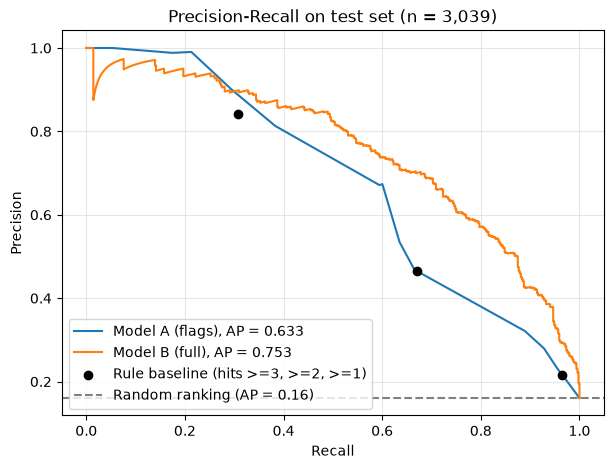

In [6]:
# Cell M4-16(code)|固定名單規模的精確率比較 + PR 曲線 + AP

def top_k_metrics(prob: pd.Series, k: int) -> tuple:
    """取機率分數最高的 k 人為名單,回傳(真陽性人數, 精確率%, 召回率%)(機率分數:模型對每位客戶算出的流失機率)。"""
    # 同分時以 clientnum 由小到大排,使名單不受排序的內部順序影響(模型 A 只有 16 個機率值,同分情形常見) 
    # true_positive 是:名單裡「真的流失」的人數,第 1 節 1.7 混淆矩陣的「真陽性」
    top = test.assign(prob=prob.values).sort_values(["prob", "clientnum"], ascending=[False, True]).head(k)
    tp = int(top["is_churned"].sum())
    return tp, round(100 * tp / k, 2), round(100 * tp / N_CHURN_TEST, 2)

rows = []
for k, rule_label in [(K3, "命中 ≥3"), (K2, "命中 ≥2")]:
    rule_row = baseline[baseline["rule"] == rule_label].iloc[0]
    rows.append({"list_size": k, "method": f"規則 {rule_label}", "true_positive": int(rule_row["true_positive"]),
                 "precision_pct": rule_row["precision_pct"], "recall_pct": rule_row["recall_pct"]})
    for name, prob in [("模型 A 旗標模型", p_a), ("模型 B 完整模型", p_b)]:
        tp, prec, rec = top_k_metrics(prob, k)
        rows.append({"list_size": k, "method": name, "true_positive": tp, "precision_pct": prec, "recall_pct": rec})
comparison = pd.DataFrame(rows)
display(comparison)

ap_a = average_precision_score(test["is_churned"], p_a)
ap_b = average_precision_score(test["is_churned"], p_b)
print(f"平均精確率 AP:模型 A {ap_a:.3f} | 模型 B {ap_b:.3f} | 隨機排序 {test['is_churned'].mean():.3f}")

# PR 曲線(圖表文字用英文,判讀用中文,[M2-12])
fig, ax = plt.subplots(figsize=(7, 5))
for name, prob, ap in [("Model A (flags)", p_a, ap_a), ("Model B (full)", p_b, ap_b)]:
    prec_curve, rec_curve, _ = precision_recall_curve(test["is_churned"], prob)
    ax.plot(rec_curve, prec_curve, label=f"{name}, AP = {ap:.3f}")
ax.scatter(baseline["recall_pct"] / 100, baseline["precision_pct"] / 100, color="black", zorder=5,
           label="Rule baseline (hits >=3, >=2, >=1)")
ax.axhline(test["is_churned"].mean(), color="grey", linestyle="--", label="Random ranking (AP = 0.16)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall on test set (n = 3,039)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Cell M4-16.1(markdown)|PR 圖與 AP : 定義說明、上圖案例說明

**PR 曲線與 AP 的定義說明:**<br/>
1. PR 曲線:把門檻從最嚴（只圈 1 人）一路放寬到最鬆（圈全部人）,每個門檻都算一組（召回率, 精確率）,連起來就是一條曲線。曲線上每一點代表一種名單規模。<br/>
2. 「平均精確率（AP）」是把整條曲線壓成一個數字:各種召回率下精確率的平均,0 到 1,越高代表「不管名單取多大,精確率都比較高」。<br/>
3. 「隨機排序」是一個對照組:假設模型完全沒能力、隨便排,那麼不管取幾人,名單的流失率都會等於全體的 16.07%,所以它的曲線是一條 0.16 的水平線、AP = 0.16。算它是為了給一個「最低及格線」:AP = 0.16 是「模型有沒有能力」的最低標準,任何有一點能力的模型都會超過它,超過它不代表值得使用;本案判斷模型值不值得用,是看它有沒有贏過 M2 已經有的 C3-b 規則基準,因為 C3-b 規則是零成本的現成方案,模型至少要比現成方案好,才有引入的理由。<br/>

**AP 與 16.07% 的觀念說明**:<br/>
1. 「AP 是什麼」：AP 不是「模型預測的流失率」，它是名單精確率的平均。做法是把名單從 1 人一路放大到全部 3,039 人，每一種名單規模都算一次精確率（名單裡幾成真的流失），再把這些精確率平均起來。<br/>
用模型 B 的實際數字：名單 178 人時精確率 90%，703 人時 56%，名單放大到全部 3,039 人時精確率就是全體流失率 16%（因為全部人都在名單裡）。從 90% 一路降到 16% 的這些精確率平均起來，就是 AP 0.753。<br/>
2. 隨機排序：如果模型完全沒有能力、名單是隨便挑的，那不管名單取 178 人、703 人還是 3,039 人，名單裡真的流失的比例都會是 16% 左右（隨便挑的人跟全體長得一樣）。每一種規模都是 16%，平均起來就是 0.16。<br/>
所以 16.07% 是「最低及格線」的意思是：一個沒有任何排序能力的模型，AP 就是 0.16；模型的 AP 高於 0.16，代表它確實把流失者排到了前面（前面的名單精確率高於 16%，平均才拉得起來）。AP 越高，代表名單越小的時候精確率越高。「模型的 AP 為什麼會比 0.16 高」：因為模型 B 取 178 人時精確率是 90%，不是 16%，它有把流失者排在前面的能力；只有完全亂猜的模型才會每種規模都是 16%。<br/>
3. 模型真正要贏的對象是 C3-b 規則，不是亂猜:<br/>
C3-b 規則基準也不是亂猜，它取 178 人時精確率 84%、703 人時 47%，早就遠高於 16%。所以模型只贏亂猜沒有用，它要在「同樣名單規模」下精確率比C3-b 規則基準更高（90% vs 84%、56% vs 47%）才有引入的理由。因為 C3-b 規則基準沒有完整的曲線、算不出 AP，所以「模型是否贏 C3-b 規則」是用固定名單規模來比精確率，不是比 AP。<br/>

**上圖案例說明:**<br/>
1. 橫軸召回率:名單圈住全部流失者的幾成。<br/>
2. 縱軸精確率:名單裡有幾成真的流失。<br/>
3. 兩條曲線是:模型 A、B 各自從最嚴到最鬆門檻的所有名單;曲線越靠右上，表示「在同樣召回率下,精確率越高」。<br/>
4. 模型 A 的曲線是階梯狀，因為它只有 16 種機率值。<br/>
5. 三個黑點(Rule Baseline)是 C3-b 規則基準的三種名單（命中 ≥3、≥2、≥1，hits 就是命中旗標數）,各自對應一組（召回率, 精確率）:(0.31, 0.84)、(0.67, 0.47)、(0.97, 0.22)。<br/>
6. 灰色虛線是隨機排序的 0.16。<br/>
7. 圖例的 AP 是各曲線下的面積：模型 A 0.633、模型 B 0.753。

In [7]:
# Cell M4-17(code)|混淆矩陣(模型 B,名單規模 178 人的門檻)+ 五個切分的穩定性檢查

# 1. 混淆矩陣:找出「機率排名第 178 名的客戶」的「機率分數」作為門檻,列出四格人數
threshold_k3 = float(np.sort(p_b.values)[::-1][K3 - 1])
listed = (p_b >= threshold_k3).astype(int)
cm = pd.crosstab(listed.rename("model_listed"), test["is_churned"].rename("actual_churned"))
print(f"模型 B 門檻 = {threshold_k3:.4f}(名單規模 {int(listed.sum())} 人)")
display(cm) 

# 對照:預設門檻 0.5 的名單 (很多工具預設以 0.5 為門檻,列出 0.5 為門檻的名單以說明「0.5 只是慣用值,不是本案的最佳門檻」,門檻應依名單規模與預算決定)
listed_50 = (p_b >= 0.5).astype(int)
tp_50 = int(((listed_50 == 1) & (test["is_churned"] == 1)).sum())
print(f"門檻 0.5:名單 {int(listed_50.sum())} 人,真陽性 {tp_50},精確率 {100*tp_50/listed_50.sum():.2f}%,召回率 {100*tp_50/N_CHURN_TEST:.2f}%")

# 2. 穩定性檢查:換五個 random_state,重做切分 → 重新訓練模型 A 與模型 B → 固定名單規模,去比精確率 
def run_once(seed: int) -> dict:
    tr_i, te_i = train_test_split(df.index, test_size=TEST_SIZE, stratify=df["is_churned"], random_state=seed)
    tr, te = df.loc[tr_i], df.loc[te_i]
    ma = sm.Logit(tr["is_churned"], sm.add_constant(tr[A_COLS].astype(float))).fit(disp=0)
    xb_tr, m, s = build_design(tr)
    xb_te, _, _ = build_design(te, m, s)
    xb_te = xb_te.reindex(columns=xb_tr.columns, fill_value=0.0)
    mb = sm.Logit(tr["is_churned"], sm.add_constant(xb_tr)).fit(disp=0, maxiter=200)
    pa = ma.predict(sm.add_constant(te[A_COLS].astype(float)))
    pb = mb.predict(sm.add_constant(xb_te))
    def prec(p: pd.Series, k: int) -> float:
        """取機率最高的 k 人,回傳名單精確率(%)。"""
        top = te.assign(p=p.values).sort_values(["p", "clientnum"], ascending=[False, True]).head(k)
        return round(100 * top["is_churned"].mean(), 1)    
    k3, k2 = int((te["hit_count"] >= 3).sum()), int((te["hit_count"] >= 2).sum())
    return {"seed": seed,
            "rule_p@k3": round(100 * te[te["hit_count"] >= 3]["is_churned"].mean(), 1), "A_p@k3": prec(pa, k3), "B_p@k3": prec(pb, k3),
            "rule_p@k2": round(100 * te[te["hit_count"] >= 2]["is_churned"].mean(), 1), "A_p@k2": prec(pa, k2), "B_p@k2": prec(pb, k2),
            "AP_A": round(average_precision_score(te["is_churned"], pa), 3), "AP_B": round(average_precision_score(te["is_churned"], pb), 3),
            "p_age": round(mb.pvalues["customer_age"], 3),
            "p_doctorate": round(mb.pvalues["education_level_Doctorate"], 3),
            "p_amt_chng": round(mb.pvalues["total_amt_chng_q4_q1"], 3)}

stability = pd.DataFrame([run_once(s) for s in [0, 1, 7, 42, 99]])
display(stability)
# 精確率增量:模型 B 的精確率比 C3-b 規則基準高出的百分點數
print("模型 B 相對 C3-b 規則的精確率增量(個百分點):",
      f"K3 平均 +{(stability['B_p@k3'] - stability['rule_p@k3']).mean():.1f},",
      f"K2 平均 +{(stability['B_p@k2'] - stability['rule_p@k2']).mean():.1f}")

模型 B 門檻 = 0.8044(名單規模 178 人)


actual_churned,0,1
model_listed,,
0,2533,328
1,18,160


門檻 0.5:名單 377 人,真陽性 284,精確率 75.33%,召回率 58.20%


,seed,rule_p@k3,A_p@k3,B_p@k3,rule_p@k2,A_p@k2,B_p@k2,AP_A,AP_B,p_age,p_doctorate,p_amt_chng
0,0,83.6,86.7,91.5,48.2,48.2,56.2,0.653,0.762,0.148,0.027,0.342
1,1,81.9,83.5,91.2,47.0,46.6,54.8,0.642,0.770,0.100,0.319,0.593
2,7,85.2,82.1,92.0,46.5,46.5,55.5,0.621,0.766,0.017,0.104,0.040
3,42,84.3,86.5,89.9,46.5,46.5,56.3,0.633,0.753,0.006,0.020,0.013
4,99,81.4,84.7,88.7,47.7,47.7,55.9,0.630,0.746,0.215,0.083,0.280


模型 B 相對 C3-b 規則的精確率增量(個百分點): K3 平均 +7.4, K2 平均 +8.6


Cell M4-18(markdown)|第 7 節判讀

**第 7 節判讀|模型評估**

- **實測**:<br/>
178 人名單(對應 C3-b 規則基準 命中 ≥3):規則精確率 84.27%、模型 A 86.52%、模型 B 89.89%;<br/>
703 人名單(對應 C3-b 規則基準 命中 ≥2):規則 46.51%、模型 A 46.51%、模型 B 56.33%,召回率由 67.01% 提高到 81.15%。<br/>
平均精確率:模型 A 0.633、模型 B 0.753、隨機排序 0.161。<br/>
混淆矩陣(模型 B,門檻 0.8044,178 人名單):列入且流失(真陽性) 160 人、列入但留存(偽陽性) 18 人(誤圈)、未列入但流失(偽陰性) 328 人(漏抓)、未列入且留存(真陰性) 2,533 人。<br/>
五個切分的穩定性檢查:<br/>
模型 B 在每一個切分都勝過 C3-b 規則基準,178 人名單平均高 7.4 個百分點(最小 +5.6)、703 人名單平均高 8.6 個百分點(最小 +7.8);<br/>
模型 A 與 C3-b 規則基準 在每一個切分都相差在 ±5 個百分點內、互有高低,703 人名單幾乎相同。<br/>


- **判定**:<br/>
(1) 模型 A 沒有勝過 C3-b 規則:<br/>
模型 A 與 C3-b 規則 使用的資訊與規則完全相同(四個旗標),差別只在「模型 A 的各旗標權重由資料學出」,而 「C3-b 規則基準是每個旗標各算一分(相等權重)」,結果顯示相等權重的命中數已抓到大部分排序資訊,模型 A 學出的權重沒有帶來額外的名單品質。<br/>
另一個證據:模型 A 的預測機率只有 16 種不同的值(四個旗標各只有 0/1 兩種值,四個旗標的組合最多 2 × 2 × 2 × 2 = 16 種)(三個交互項由四個旗標決定,不增加組合數),所以模型 A 對 3,039 人只能給出 16 種不同的機率分數;如此,大量客戶的分數相同(同分),模型 A 就無法在同分客戶之間分出先後順序,最終模型 A 的效果與 C3-b 規則基準的「五層命中數」的解析度相同粗糙。<br/>
(2) 模型 B 明顯勝過 C3-b 規則:<br/>
在相同名單規模下,模型 B 的精確率高出 7 至 9 個百分點,且五個切分皆成立,達到第 4 節判讀訂的「高出 5 個百分點以上且五個切分皆成立」的標準。<br/>
以 703 人名單為例,模型 B 圈到 396 名流失者、規則圈到 327 名,模型多圈到 69 名;名單人數固定為 703,多抓 69 名流失者就等於少誤圈 69 名不會流失的客戶(模型誤圈 703 − 396 = 307 人,C3-b 規則誤圈 703 − 327 = 376 人)。<br/>
以 178 人的名單為例,模型 B 的 178 人中有 160 人真的流失,誤圈只有 18 人。<br/>
(3) 門檻 0.5 的對照:<br/>
很多工具預設以 0.5 作為門檻(機率 ≥ 0.5 就列入名單)。以 0.5 為門檻,模型 B 給出 377 人的名單,精確率 75%、召回率 58%。這三個數字剛好落在命中 ≥3 和命中 ≥2 這兩種規則名單之間:名單人數 377 介於 178 與 703 之間,精確率 75% 介於 84% 與 47% 之間,召回率 58% 介於 31% 與 67% 之間。這說明 0.5 只是一個慣用值,它產生的名單既不是最嚴的、也不是最鬆的,沒有任何理由說它最適合本案;門檻應由 M5 依預算能投放的人數與名單品質的要求來決定,不是直接預設用 0.5 作為門檻。<br/>


- **對決策的意涵**(待驗證事項 #8 結案):<br/>
(1) 模型 B 比 C3-b 規則多出的精確率,來自「連續數值」(交易 43 筆與 20 筆有差)與「旗標以外的變數」(循環欠款(本金)、不活躍月數、消費筆數變化比、婚姻狀態),不是來自旗標的加權;C3-b 規則若要改進,改進方向是納入這些變數,而不是調整四旗標的權重。<br/>
(2) M5 名單的兩個選項(待驗證事項 #25):<br/>
採用 C3-b 規則,零維護成本、對業務單位的可解釋性高、精確率 84%(178 人名單)/ 47%(703 人名單);<br/>
採用模型 B 的機率分數,給每位客戶一個流失機率、依機率分數做名單排序,精確率 90% / 56%,但需維護特徵計算與模型(每次產生名單都要重算 27 個特徵並套用模型),係數不宜當規則解讀(係數不能直接翻譯成規則交給業務單位)。<br/>
C3-b 規則與模型 B 的差距有什麼意義:以 703 人名單計,C3-b 規則每 100 個投放對象中約 47 人真的流失,模型 B 則約 56 人真的流失,模型 B 每 100 人約多抓 10 名流失者;若業務單位挽留一位客戶所需付出的成本高(例如每人數千元的優惠),少誤圈 69 人省下的成本足以支付維護模型的成本;若挽留成本低,使用 C3-b 規則即可。此為 M5 的成本效益決策,新增待驗證事項 #25。<br/>
(3) 若 M5 採用 C3-b 規則,「命中旗標數 ≥3」對應精確率 84%、「命中旗標數 ≥2」對應 47%,兩者之間可加入「循環欠款(本金)低」、「不活躍月數高」作為介於兩者之間的第三種名單條件的候選。<br/>


- **待辦或限制**:<br/>
(1) 精確率的數字有抽樣波動:<br/>
測試集只有 3,039 人,178 人的名單裡每多一位或少一位真的流失的客戶,精確率就改變 1 ÷ 178 ≈ 0.6 個百分點,所以單一次切分算出的「模型 B 比 C3-b 規則高 5.6 個百分點」這種數字本身帶有波動。M4 因此以五個切分的平均(+7.4、+8.6 個百分點)作為結論,不以 random_state = 42 這一次的數字作為結論。<br/>
(2) 精確率的比較只在 178 人與 703 人這兩種名單規模下做過:<br/>
模型 B 與 C3-b 規則的精確率差距會隨名單規模改變(名單越大,兩者的精確率都會下降,精確率差距也可能不同)。若 M5 決定的名單規模不是這兩種(例如預算只夠投 400 人),必須用 M5 決定的規模重新算一次模型 B 與 C3-b 規則的精確率,不能直接沿用本節的數字。<br/>
(3) 模型 B 的機率分數沒有做校準(calibration):<br/>
校準是檢查「模型說某群客戶有 80% 會流失,實際上這群客戶是不是真的有 80% 流失」。本模組只用機率分數排序、取前 N 人,排序的先後不受校準影響,所以名單的精確率不受影響;但 M5 若要把機率分數當作「流失可能性的百分比」寫進報告或對業務單位說明(例如「這位客戶有 80% 機率會流失」),機率值本身就必須準確,那時要先做校準。<br/>
校準的常見檢查方式是可靠性圖:橫軸為模型給出的機率、縱軸為該機率區間客戶的實際流失比例,兩者一致時會落在對角線上;若不一致,再以校準方法調整機率值。M4 沒做,列為限制。<br/> 
(4) 邊際變數的 p 值在切分間變動(第 7 節穩定性表最後三欄:年齡、Doctorate、消費變化比的 p 值在不同切分有時低於 0.05、有時高於 0.05):<br/>
這說明個別係數的顯著與否,會隨樣本不同而改變(因為每次切分的樣本不一定相同,若該變數的真實效果很小、勝算比接近 1,影響力不明顯,就可能因樣本變化而導致每次切分的 p 值不穩定,p 值會在 0.05 附近隨著樣本擺盪),所以 M4 的結論(模型 B 勝過 C3-b 規則)是建立在「測試集的名單精確率」上,不是建立在「哪些係數顯著」上;讀者不應從係數表挑出某個變數顯著就下結論。<br/>

Cell M4-19(markdown)|第 8 節:模型結論

## 第 8 節|模型結論(決策日誌 [M4-4])

1. **C3-b 規則 → 簡單模型 → 完整模型的比較結果**:<br/>
(1)本模組依「先用最簡單的方法,再逐步加入複雜度,每一階都要證明比前一階好」的順序比較三種方法。第一階 C3-b 規則(四旗標命中數)與第二階旗標模型 A 的名單品質相當,證明 M2 的四條規則已抓到旗標資訊能提供的全部排序價值;第三階完整模型 B 在相同名單規模下精確率高出 7 至 9 個百分點、703 人名單的召回率提高 14 個百分點,這些增量來自連續數值與四旗標以外的行為變數。<br/>
(2)為什麼不再往上做樹模型或集成模型(決策日誌 [M4-0]):理由有三:
第一,本專案的模型用途是支持 M5 的挽留名單與策略,名單條件必須能對業務單位說明並寫成可維護的規則,邏輯斯迴歸的每個係數都能翻譯成「某屬性每增加一單位,流失勝算變幾倍」,樹模型與集成模型做不到這種說明。<br/>
第二,從模型 A 到模型 B 的增量(7 至 9 個百分點)已經來自「用了更多資訊」,樹模型用的資訊與模型 B 相同,它多出來的只是能自動捕捉非線性與交互作用,而本案最重要的交互作用(淺關係 × 低活躍)已經用交互項處理,預期樹模型的額外增量不大。<br/>
第三,每多一種模型就多一套要維護、要解釋的東西,以本案「支持決策」的目的,增加的解釋成本高於預期的精確率收益。若未來業務需求變成「只要名單精確率最高、可忽略解釋成本」,再評估在本案應用樹模型。<br/>
(3)「增量」意指:預期增加的精確率幅度。<br/>

2. **風險訊號的最終排序**(其他條件相同時,每增加一個標準差的勝算比):<br/>
交易筆數(0.06,最強)、交易金額(需與筆數合併解讀)、循環欠款(本金)(0.46)、往來產品數(0.49)、筆數變化比(0.50)、不活躍月數(1.64)、聯繫次數(1.85);人口屬性中,「性別」與「婚姻」顯著且穩定,年齡、收入、教育不顯著或在切分間不穩定。<br/>
全案「流失是行為問題,不是人口屬性問題」的敘事在多變數模型中成立,唯一的例外是性別,交由 M7 處理。<br/>


3. **交互作用的修正**:<br/>
只有淺關係與低活躍存在交互作用(勝算尺度與百分點尺度皆成立)。<br/>
零動用與高聯繫為獨立主效果,M2 C2 判讀中「零動用效果與高聯繫效果集中於低活躍子群」的敘述僅在百分點尺度成立,M8 引用時須改寫。<br/>

4. **對 M5 的建議:**<br/>
(1)名單條件:「淺關係且低活躍」是最強的組合條件(兩者同時成立時,流失勝算在各自效果相乘之外再乘 3.36 倍),應列為名單的最高優先層;「零動用」與「高聯繫」在模型中是獨立的主效果,意思是它們單獨成立時就會提高風險,不需要「同時低活躍」才算數,所以 M5 可以把「零動用」「高聯繫」各自列為獨立的名單條件,不必限定只在低活躍客戶中使用(這一點修正了 notebook 02 C2 判讀第三點對 M5 的建議)。四個旗標的勝算比大小(低活躍 21.4 > 零動用 6.0 > 淺關係 5.1 > 高聯繫 4.4)可作為 M5 給旗標加權的依據。<br/>
(2)名單圈選方式:在「C3-b 規則」與「模型 B 機率分數」之間選擇,依據是業務單位挽留一位客戶的成本與維護模型的成本;M4 提供兩者在 178 人與 703 人名單規模下的精確率(84% vs 90%、47% vs 56%)作為 M5 決策的輸入(待驗證事項 #25)。

Cell M4-20(markdown)|第 9 節:方法限制

## 第 9 節|方法限制

1. **模型只能證明關聯,不能證明因果**:<br/>
「關聯」指的是「屬性 A 高的客戶,流失率也比較高」這種同時出現的關係/現象;「因果」指的是「把屬性 A 改變,流失率就會跟著改變」。模型的勝算比只能證明前者。<br/>
具體例子:<br/>
(1)交易筆數的勝算比 0.06,意思是「其他條件相同時,交易筆數多 23.5 筆的客戶,流失勝算只有原本的 6%」,這是關聯;它不代表「讓客戶多刷 23.5 筆卡,他的流失勝算就會降到 6%」,因為很可能是已經決定離開的客戶自然不再刷卡,筆數低是流失的結果而不是原因。<br/>
(2)交易金額的係數在控制筆數後翻轉為正向(第 6 節判讀),更說明:模型的單一係數只在「其他變數固定」的前提下才有意義,不能拿出來當作「改變它就能改變流失」的依據。<br/>
小結:<br/>
挽留策略(例如深化往來、主動聯繫)是否真的能降低流失,必須由 M6 的實驗驗證,M4 不能回答。<br/>

2. **行為欄位是近 12 個月的彙總值,無法區分行為改變與流失決定的先後**:<br/>
每位客戶的交易筆數、交易金額、額度動用率都是快照時點往前 12 個月的加總;一位在第 6 個月就流失的客戶,後面 6 個月沒有任何交易,他的年度交易筆數與交易金額必然偏低。<br/>
模型從資料學到「交易筆數低的客戶流失率高」,其中一部分只是「先流失、所以交易筆數低」,不是「先交易筆數低、後來才流失」。因此 M4 的精確率代表的是「在快照時點,模型能否正確辨識哪些客戶是高風險」,不代表可以判斷「在客戶決定離開之前多久的時間點,模型就能把他排在流失高風險名單的前面」。要評估後者(哪個時間點可以先預警),需要有「每筆交易日期或每月快照的資料(有時間戳記的資料)」,本案的資料集沒有這種資料。

3. **聯繫次數以連續變數納入,假設每多一次的效果相同**:<br/>
模型 B 對聯繫次數「只學一個係數」,意思是「每多聯繫一次,流失勝算都乘同一個倍數 1.85」。但 M2 的切片曲線顯示每多一次的效果並不相同:從 0 次到 1 次,流失率由 1.75% 跳到 7.20%(差很多);從 3 次到 4 次,流失率由 20.15% 到 22.63%(差很少);從 5 次到 6 次,流失率由 33.52% 到 100%(差極多)。<br/>
若用同一個倍數描述這條忽大忽小的曲線,模型在中段會高估、在兩端會低估,尤其對聯繫 6 次的客戶(實際 100% 流失),模型算出的機率會明顯低於 100%。<br/>
替代做法:把 5 次與 6 次合併為「≥5 次」後以類別變數納入,能保留曲線形狀,但係數變多、5 與 6 次的差別消失,第 6 節已說明 M4 不採用此替代做法的理由。<br/>

4. **模型 B 的機率分數未做校準**:<br/>
校準是檢查「模型給出 80% 流失機率的那群客戶,實際上是否真的有 80% 流失」。M4 只用機率分數的高低排序、取排名的前 N 人為名單,名單的精確率不受校準影響;但若 M5 要把機率分數當作「流失可能性百分比」寫進報告或對客戶經理說明,機率值本身就必須準確,那時就要先做校準。M4 未做,列為限制。<br/>

5. **M4 未做的方法與不做的理由**:<br/>
M4 沒有做決策樹、隨機森林等樹模型,沒有做集成模型,沒有做 SHAP 之類的事後解釋工具,也沒有做超參數調整(在訓練機器學習模型之前，手動設定並找出最佳超參數組合的過程，用來讓模型的預測效能達到最好)。理由見第 8 節第 1 點:本專案的模型用途是支持「可對業務單位說明的名單與策略」,邏輯斯迴歸已在相同名單規模下勝過 C3-b 規則 7 至 9 個百分點,更複雜的方法用的資訊相同、預期的額外增量不大,而解釋與維護成本明顯更高。若未來業務需求轉為「只追求名單精確率、可忽略解釋成本」,再評估樹模型。<br/>

6. **性別作為特徵的疑慮**:<br/>
模型 B 顯示女性的流失勝算比為 2.12(五個切分介於 2.1 至 3.0,皆統計顯著)。若 M5 直接用這個模型圈名單,女性客戶會被系統性地排在較高風險,挽留資源的分配就會因性別而不同,可能在法遵與公平性上有疑慮。M4 不決定是否保留性別作為圈選名單的依據,而是把這個疑慮交由 M7 檢視:跑一版不含性別的模型,比較精確率會損失多少,再依法遵角度決定名單是否允許用性別作為依據(待驗證事項 #27)(詳參 Cell M4-14 說明)。<br/>

Cell M4-21(markdown)|第 10 節:待驗證事項清單 v5 與 M5 開工檢核

## 第 10 節|待驗證事項清單 v5(M4 收尾定版)

**定位**:承接 notebook 03 Cell M3-23 的 v4,回填本模組承接的 #6、#7、#8、#18、#19、#20,並新增本模組產生的待辦(#24 起)。編號沿用,不重編;v4 其餘項目原文照抄。

**M4 (本模組)結案的項目**:

| # | 事項 | 結案結果 | 依據 |
|---|---|---|---|
| 6 | 建模時評估納入交互項(low_activity 分別乘上零動用 / 淺關係 / 高聯繫) | ✅ 完成:淺關係交互項顯著且勝算比 3.36(兩種尺度皆成立);零動用交互項不顯著(p = 0.246);高聯繫交互項顯著但勝算比 0.36,在勝算尺度為負向(方向與 C2 相反),高聯繫對活躍正常客戶的倍數效果反而更大。<br/> C2「三訊號效果皆集中於低活躍子群」的敘述僅在百分點尺度成立,M8 引用須註明尺度(改成「只有淺關係與低活躍存在交互作用,零動用與高聯繫則是各自獨立的主效果」。因為在勝算尺度下:只有淺關係成立,零動用無交互作用,高聯繫則方向相反)(見 #24) | notebook 04 第 5 節判讀 |
| 7 | 檢查旗標特徵之間的相關性對迴歸係數穩定性的影響 | ✅ 完成:模型 B 全部 27 個特徵 VIF 最大 3.44,低於 5,不需處理;但交易筆數與交易金額相關 0.808 使金額係數在控制筆數後方向翻轉為正,判讀已說明;avg_open_to_buy 因恆等式排除 | notebook 04 第 6 節判讀、第 2 節 |
| 8 | M4 模型評估報告必須附上與 C3-b 命中數分層基準的成績比較 | ✅ 完成:固定名單規模,比精確率。模型 A 與 C3-b 規則相當(相差在 ±5 個百分點內、互有高低);模型 B 在178 人名單平均高 C3-b 規則 7.4 個百分點、703 人名單平均高 C3-b 規則 8.6 個百分點,五個切分皆成立 | notebook 04 第 7 節判讀 |
| 18 | tenure 進模型的兩項注意(與 age 相關 0.7889;tenure=36 單值聚集) | ✅ 完成:二擇一選 customer_age,months_on_book 未進模型;年齡在本切分 p = 0.006,但五個切分間 p 值於 0.006 至 0.215 變動,屬邊際變數 | notebook 04 第 2 節、第 7 節穩定性表 |
| 19 | 6 次組流失率 100% 在 logistic regression 中造成完全分離 | ✅ 完成:聯繫次數以「連續變數」形式納入模型,分離消失;代價(假設「每多聯繫一次,效果相同」,與 M2 曲線形狀兩端不符),細節寫於第 6 節與第 9 節限制 3 | notebook 04 第 6 節 |
| 20 | M4 係數以勝算比解讀時,與 T2 單變數勝算比(2.43)對照 | ✅ 完成:單變數:2.43 → 四主效果模型(模型 A):9.62 → 含交互項模型(模型 B):5.11(活躍正常子群)/約 17.2(低活躍子群);單變數偏小的原因是淺關係客戶較少為低活躍(25.4% vs 全體 41.1%),控制後淺關係效果才完整顯現 | notebook 04 第 5 節判讀 |

**交辦後續模組的項目**(v4 既有項目維持原文,M4 新增 #24 至 #27):

| # | 事項 | 為什麼要做 | 交辦階段 | 依據 |
|---|---|---|---|---|
| 9 | 挽留名單門檻(命中旗標數 ≥2 或 ≥3)依預算與成本效益定案 | 覆蓋率與精準度無法兩全,屬商業決策 | M5 | notebook 02 Cell C-10、[M2-9] |
| 10-a | 高聯繫預警線位置(現為 ≥4 次的工作預設值)依成本效益定案 | T1 證明關聯真實但不指出門檻;4 次組 diff_pp +6.56 未達實務判準,5 次以上遠超過但人數僅 230 人 | M5 | notebook 02 Cell 21 註、notebook 03 T1 判讀、[M2-5] |
| 17 | H3 消費變化比的門檻位置:0.604 僅為五分位箱界,非精確門檻 | 若 M5 採「變化比 < X 即示警」規則,X 需要更準的定位:對 0.4–0.8 區間做更細分箱(如十分位),觀察流失率跳升的確切位置 | M5 | notebook 02 Cell 27 |
| 21 | M5 名單條件應為「淺關係且低活躍」,不以「淺關係」單獨成立;估算預期效益時以 T2 信賴區間下限 11.74 個百分點做保守估計 | T2 通過的是全體平均差距,C2 顯示效果集中於低活躍子群;M4 模型 A 確認此交互作用在勝算尺度亦成立 | M5 | notebook 03 T2 判讀、notebook 04 第 5 節判讀 |
| 22 | M5 價值軸以 total_trans_amt 分高、中、低價值層,切點(如三分位或依業務金額)由 M5 定案;判讀時說明「近 12 個月彙總值對中途流失客戶偏低」的代理雜訊 | T4 確認交易金額能區分客群,但價值層切點與代理雜訊的說明不在 M3 範圍 | M5 | notebook 03 T4 判讀 |
| 25 | M5 名單圈選方式在「C3-b 規則(命中數)」與「模型 B 機率分數」之間選擇:C3-b 規則零維護成本、可解釋,精確率 84% / 47%;模型 B 精確率 90% / 56%(178 / 703 人名單),需維護特徵計算與模型 | 兩者的名單品質差距已量化,選擇取決於單位挽留成本與維護成本 | M5 | notebook 04 第 7 節判讀、第 8 節 |
| 26 | 零動用與高聯繫在模型中為獨立主效果,M5 名單可將兩者列為「不限定於低活躍子群的獨立條件」;四個旗標的勝算比排序(低活躍 21.4 > 零動用 6.0 > 淺關係 5.1 > 高聯繫 4.4)可作為 C3-b 規則加權的依據 | 修正 notebook 02 C2 判讀第三點對 M5 的建議 | M5 | notebook 04 第 5 節判讀 |
| 11 | 「調高額度」不得直接列為挽留手段;若要採用,須經實驗驗證 | 低額度與流失的機制未定(額度造成使用不便,或額度只是關係深度的痕跡;若為後者,調額度是處理痕跡而非成因,唯有 M6 實驗能驗證);模型 B 中額度在控制往來深度等變數後不顯著(勝算比 0.94、p = 0.32),此結果與「額度只是痕跡」的解釋相容,但不能排除另一種機制,不改變「須經實驗驗證」的要求 | M5 / M6 | notebook 02 Cell C-12、notebook 04 第 6 節判讀 |
| 15(M8 部分) | M8 簡報陳述 H6 時須明示「風險標記,非提前預警」,不得寫成因果 | 快照資料無法區分聯繫與流失決定的先後 | M8 | notebook 03 T1 判讀、[M2-5] |
| 23 | M6 樣本數計算沿用第 8 節方法(Cohen's h、α、檢定力 0.8);若同時檢定多個指標,以校正後 α 計算;「兩組人數不同的分組」或「分層隨機化」時調整計算方式 | 實驗前必須決定樣本數,事後無法補救 | M6 | notebook 03 第 8 節 |
| 24 | M8 引用 M2 C2 的交互作用結論時,須改寫為「只有淺關係與低活躍存在交互作用;零動用與高聯繫則是各自獨立的主效果」,並註明 C2 的百分點尺度與模型的勝算尺度不同 | 兩種尺度結論不同,避免簡報誤述: C2「三訊號效果皆集中於低活躍子群」的敘述僅在百分點尺度成立,M8 引用須註明尺度。<br/>因為在勝算尺度下:只有淺關係成立,零動用無交互作用,高聯繫則方向相反 | M8 | notebook 04 第 5 節判讀 |
| 27 | M7 公平性檢視:模型 B 女性的勝算比 2.12(控制其他變數後,五個切分皆顯著),以性別為特徵的模型會系統性地把女性列為較高風險;M7 應比較「含性別」與「不含性別」兩版模型的精確率,將「移除性別的代價」量化,並就法遵角度說明是否可用「性別」作為圈選名單依據 | 性別作為挽留資源分配依據的法遵與公平性風險 | M7 | notebook 04 第 6 節判讀、第 9 節限制 6、notebook 03 T3 判讀 |
| 13 | mart 層匯出:依 M8 儀表板設計定案後,一次匯出 data/processed/ 的 CSV | 下游需求(儀表板要呈現什麼)未定前匯出無驗收標準;只是延後,不是取消 | M8 | [M2-13] |
| 14 | Excel 樞紐分析重現:以樞紐表重現一張儀表板選用的切片,驗證與 SQL 數字一致,產出 churn_pivot_summary.xlsx,README 技術棧列入 Excel | 展示跨工具重現同一分析並核對數字一致的能力;與 #13 一併完成 | M8 | [M2-14] |

**清單演變紀錄**:<br/>
v4(M3 收尾) →  v5(本表:#6、#7、#8、#18、#19、#20 結案 ; #21、#11 補充 M4 結果作為對照觀察 ; 新增 #24 至 #27)。

**M5 開工檢核**(進入 M5 前先核對):<br/>
承接 #9、#10-a、#17、#21、#22、#25、#26、#11(M5 部分);M5 收尾時回填狀態,並將本表複製至 notebook 05(或 M5 的交付文件)開頭作為承接依據。